In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Loading and Exploring the Data**

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/colab datasets/train.csv')

In [ ]:
df

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [ ]:
df.isnull().sum()

,0
id,0
road_type,0
num_lanes,0
curvature,0
speed_limit,0
lighting,0
weather,0
road_signs_present,0
public_road,0
time_of_day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop(columns=['id'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 37.5+ MB


In [ ]:
df.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


In [ ]:
num_cols=df.select_dtypes(include=['int','float'])
num_cols

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
0,2,0.06,35,1,0.13
1,4,0.99,35,0,0.35
2,4,0.63,70,2,0.30
3,4,0.07,35,1,0.21
4,1,0.58,60,1,0.56
...,...,...,...,...,...
517749,4,0.10,70,2,0.32
517750,4,0.47,35,1,0.26
517751,4,0.62,25,0,0.19
517752,3,0.63,25,3,0.51


In [ ]:
cat_cols=df.select_dtypes(exclude=['int','float'])
cat_cols

,road_type,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season
0,urban,daylight,rainy,False,True,afternoon,False,True
1,urban,daylight,clear,True,False,evening,True,True
2,rural,dim,clear,False,True,morning,True,False
3,highway,dim,rainy,True,True,morning,False,False
4,rural,daylight,foggy,False,False,evening,True,False
...,...,...,...,...,...,...,...,...
517749,highway,daylight,foggy,True,True,afternoon,False,False
517750,rural,daylight,rainy,True,True,morning,False,False
517751,urban,daylight,foggy,False,False,afternoon,False,True
517752,highway,night,clear,True,False,afternoon,True,True


In [ ]:
# checking for skewness

for i in num_cols:
    print(i,num_cols[i].skew())

num_lanes 0.01277533250638846
curvature -0.03868453373471708
speed_limit 0.18115979057866655
num_reported_accidents 0.3739685270993894
accident_risk 0.37841797634228097


**Insights:-**

num_lanes	0.013	Almost perfectly symmetric

curvature	−0.039	Almost perfectly symmetric

speed_limit	0.18	Slight right skew (negligible)

num_reported_accidents	0.37	Mild right skew

accident_risk	0.38	Mild right skew

In [ ]:
# checking for kurtosis

for i in num_cols:
    print(i,num_cols[i].kurt())

num_lanes -1.3653271734570696
curvature -1.102585445112791
speed_limit -1.307646217834089
num_reported_accidents -0.31625407234748737
accident_risk -0.07669151216367043


**Insights:-**

num_lanes	-1.37	Very flat, bounded, few extremes

curvature	-1.10	Flat distribution, likely constrained values

speed_limit	-1.31	Strongly platykurtic

num_reported_accidents	-0.32	Slightly flat, closer to normal

accident_risk	-0.08	Almost normal-tailed

#### **Non Visual Analysis**

In [ ]:
for i in num_cols:
    print(num_cols[i].value_counts())
    print()

num_lanes
1    131168
2    130054
4    129118
3    127414
Name: count, dtype: int64

curvature
0.5700    8902
0.6700    8718
0.6300    8498
0.7000    8233
0.4300    8044
          ... 
0.3711       1
0.2392       1
0.2348       1
0.2376       1
0.3942       1
Name: count, Length: 261, dtype: int64

speed_limit
45    115752
35    111628
25    101422
60    100304
70     88648
Name: count, dtype: int64

num_reported_accidents
1    209674
2    145965
0    125269
3     34197
4      2392
5       231
6        24
7         2
Name: count, dtype: int64

accident_risk
0.34    15542
0.32    14240
0.37    13453
0.28    13287
0.39    12499
        ...  
0.94       47
0.97       28
0.96       28
0.90       26
0.93       23
Name: count, Length: 98, dtype: int64



In [ ]:
for i in cat_cols:
    print(cat_cols[i].value_counts())
    print()

road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

lighting
dim         183826
daylight    178015
night       155913
Name: count, dtype: int64

weather
foggy    181463
clear    179306
rainy    156985
Name: count, dtype: int64

road_signs_present
False    259289
True     258465
Name: count, dtype: int64

public_road
True     260045
False    257709
Name: count, dtype: int64

time_of_day
morning      173410
evening      172837
afternoon    171507
Name: count, dtype: int64

holiday
True     260688
False    257066
Name: count, dtype: int64

school_season
False    260164
True     257590
Name: count, dtype: int64



In [ ]:
for i in num_cols:
  print(i,df[[i,'accident_risk']].corr())
  print()

num_lanes                num_lanes  accident_risk
num_lanes       1.000000      -0.006003
accident_risk  -0.006003       1.000000

curvature                curvature  accident_risk
curvature       1.000000       0.543946
accident_risk   0.543946       1.000000

speed_limit                speed_limit  accident_risk
speed_limit       1.000000       0.430898
accident_risk     0.430898       1.000000

num_reported_accidents                         num_reported_accidents  accident_risk
num_reported_accidents                1.000000       0.213891
accident_risk                         0.213891       1.000000

accident_risk                accident_risk  accident_risk
accident_risk            1.0            1.0
accident_risk            1.0            1.0



#### **Univariate Visual Analysis**

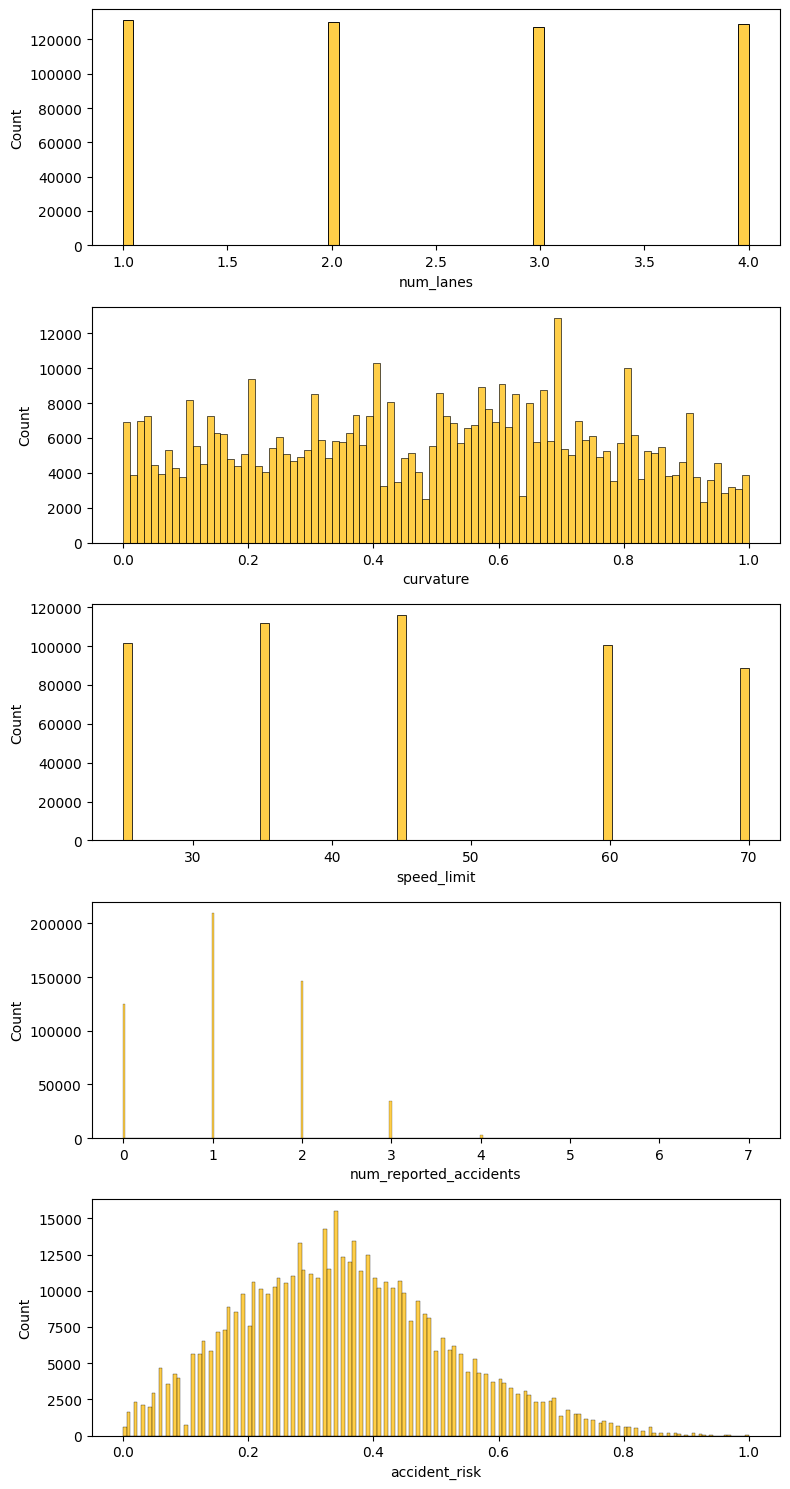

In [ ]:
# Numerical Columns
# Here Histogram shows the distribution of a single Numerical Variable

fig,axes=plt.subplots(5,1,figsize=(8, 15))

sns.histplot(num_cols,x=num_cols['num_lanes'],ax=axes[0],color='#FFBE0B')
sns.histplot(num_cols,x=num_cols['curvature'],ax=axes[1],color='#FFBE0B')
sns.histplot(num_cols,x=num_cols['speed_limit'],ax=axes[2],color='#FFBE0B')
sns.histplot(num_cols,x=num_cols['num_reported_accidents'],ax=axes[3],color='#FFBE0B')
sns.histplot(num_cols,x=num_cols['accident_risk'],ax=axes[4],color='#FFBE0B')

plt.tight_layout()
plt.show();


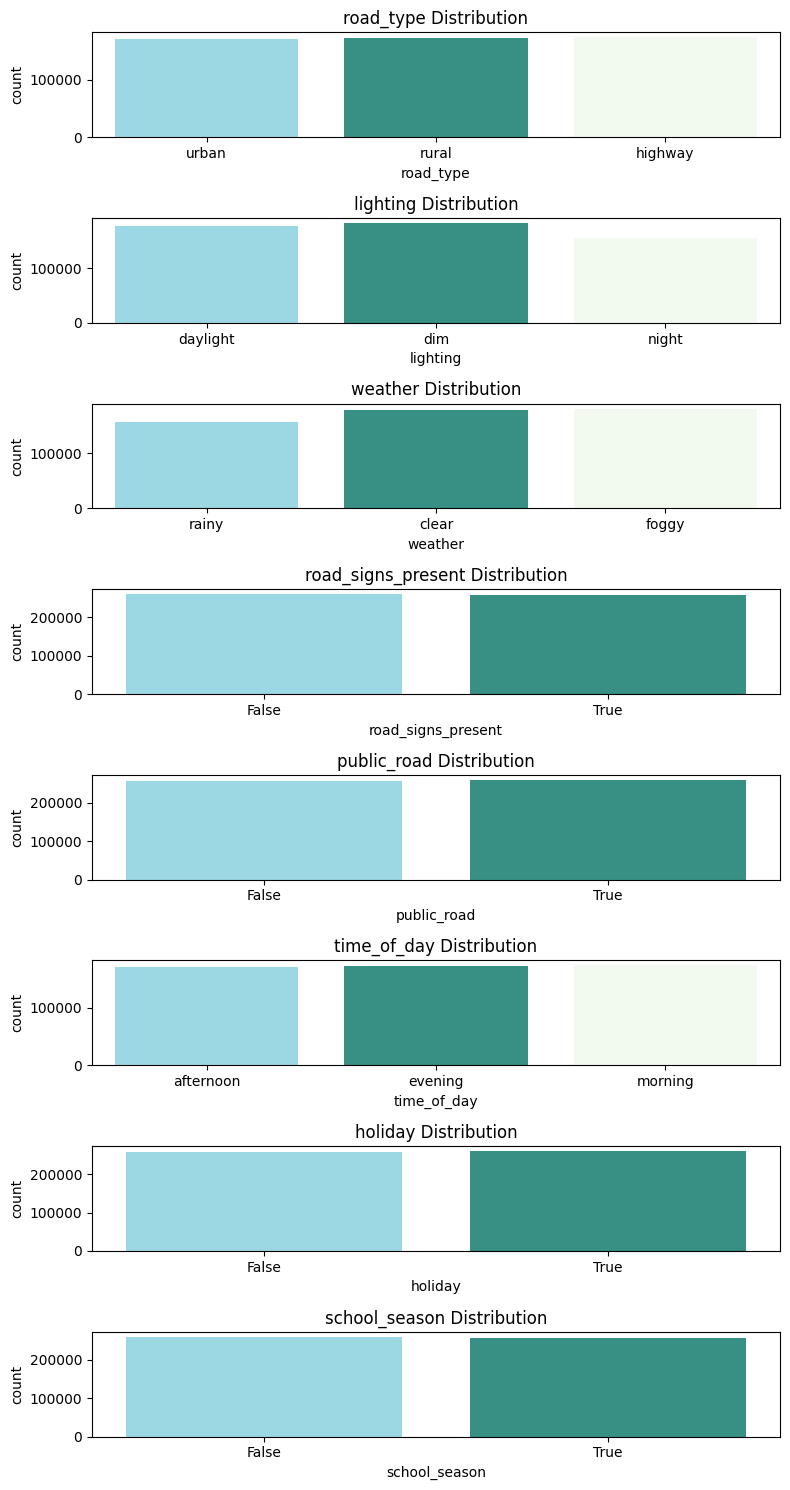

In [ ]:
# Categorical Columns
# Here Countplot shows the distribution of a single categorical Variable

fig,axes=plt.subplots(8,1,figsize=(8, 15))

sns.countplot(cat_cols,x=cat_cols['road_type'],ax=axes[0],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[0].set_title('road_type Distribution')
sns.countplot(cat_cols,x=cat_cols['lighting'],ax=axes[1],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[1].set_title('lighting Distribution')
sns.countplot(cat_cols,x=cat_cols['weather'],ax=axes[2],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[2].set_title('weather Distribution')
sns.countplot(cat_cols,x=cat_cols['road_signs_present'],ax=axes[3],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[3].set_title('road_signs_present Distribution')
sns.countplot(cat_cols,x=cat_cols['public_road'],ax=axes[4],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[4].set_title('public_road Distribution')
sns.countplot(cat_cols,x=cat_cols['time_of_day'],ax=axes[5],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[5].set_title('time_of_day Distribution')
sns.countplot(cat_cols,x=cat_cols['holiday'],ax=axes[6],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[6].set_title('holiday Distribution')
sns.countplot(cat_cols,x=cat_cols['school_season'],ax=axes[7],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[7].set_title('school_season Distribution')

plt.tight_layout()
plt.show();

In [ ]:
num_cols.columns

Index(['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents',
       'accident_risk'],
      dtype='object')

#### **Bivariate Visual Analysis**

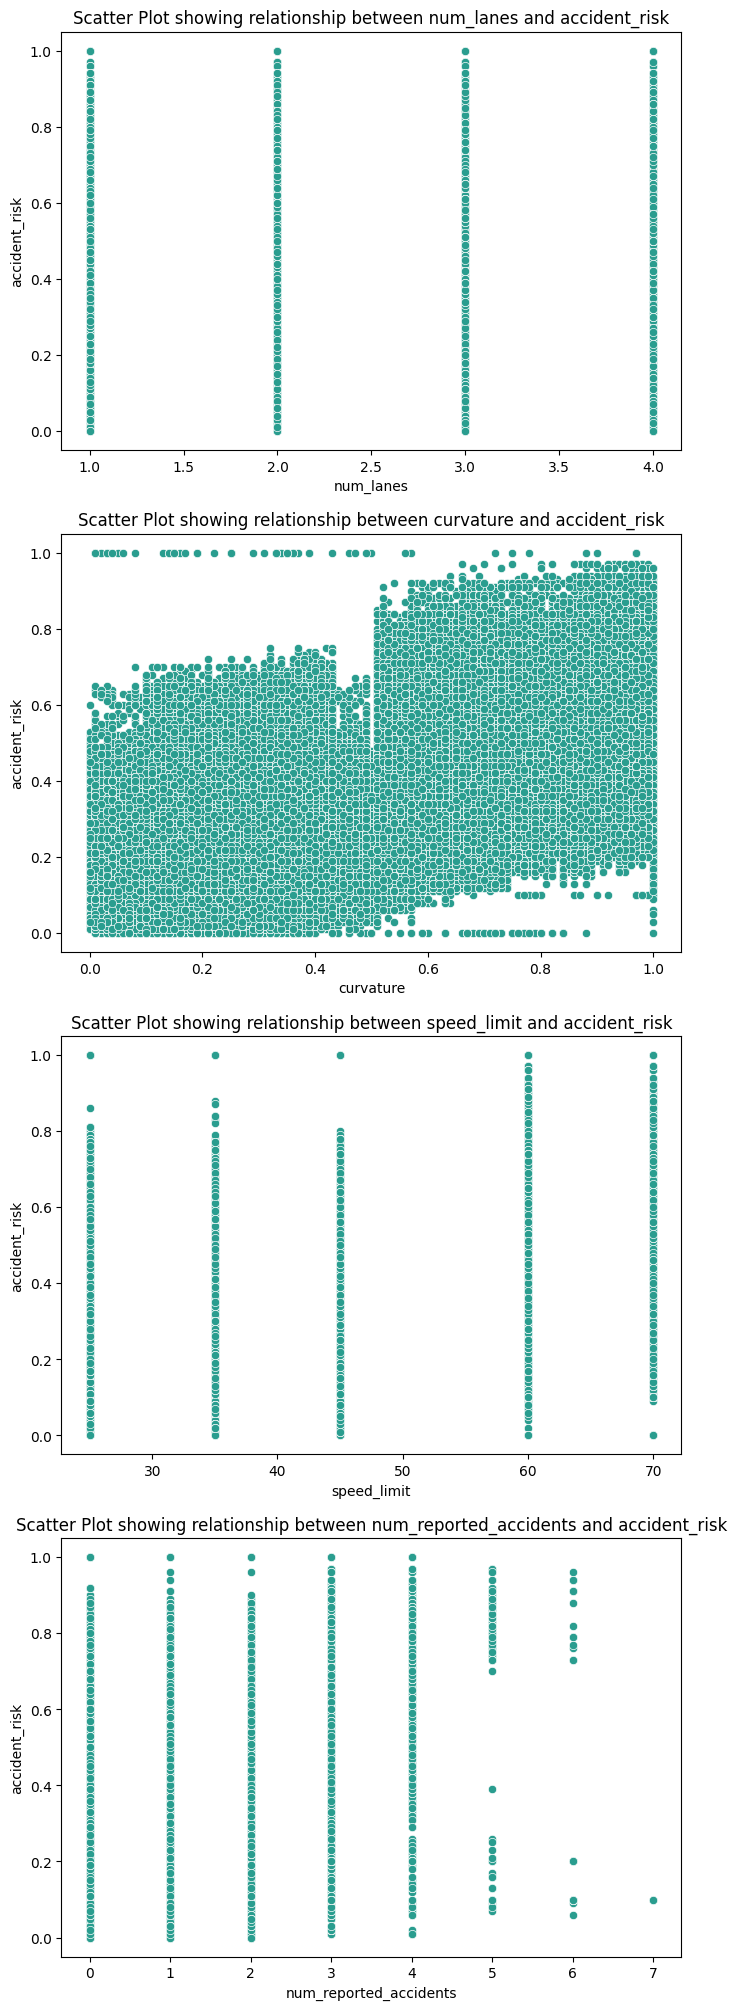

In [ ]:
# Numerical Columns
# Here scatter plot showing relation between a numerical feature and numerical target variable

fig,axes=plt.subplots(4,1,figsize=(8,25))
sns.scatterplot(data=df,x='num_lanes',y='accident_risk',ax=axes[0],color=['#2A9D8F'])
axes[0].set_title('Scatter Plot showing relationship between num_lanes and accident_risk')
sns.scatterplot(data=df,x='curvature',y='accident_risk',ax=axes[1],color=['#2A9D8F'])
axes[1].set_title('Scatter Plot showing relationship between curvature and accident_risk')
sns.scatterplot(data=df,x='speed_limit',y='accident_risk',ax=axes[2],color=['#2A9D8F'])
axes[2].set_title('Scatter Plot showing relationship between speed_limit and accident_risk')
sns.scatterplot(data=df,x='num_reported_accidents',y='accident_risk',ax=axes[3],color=['#2A9D8F'])
axes[3].set_title('Scatter Plot showing relationship between num_reported_accidents and accident_risk');

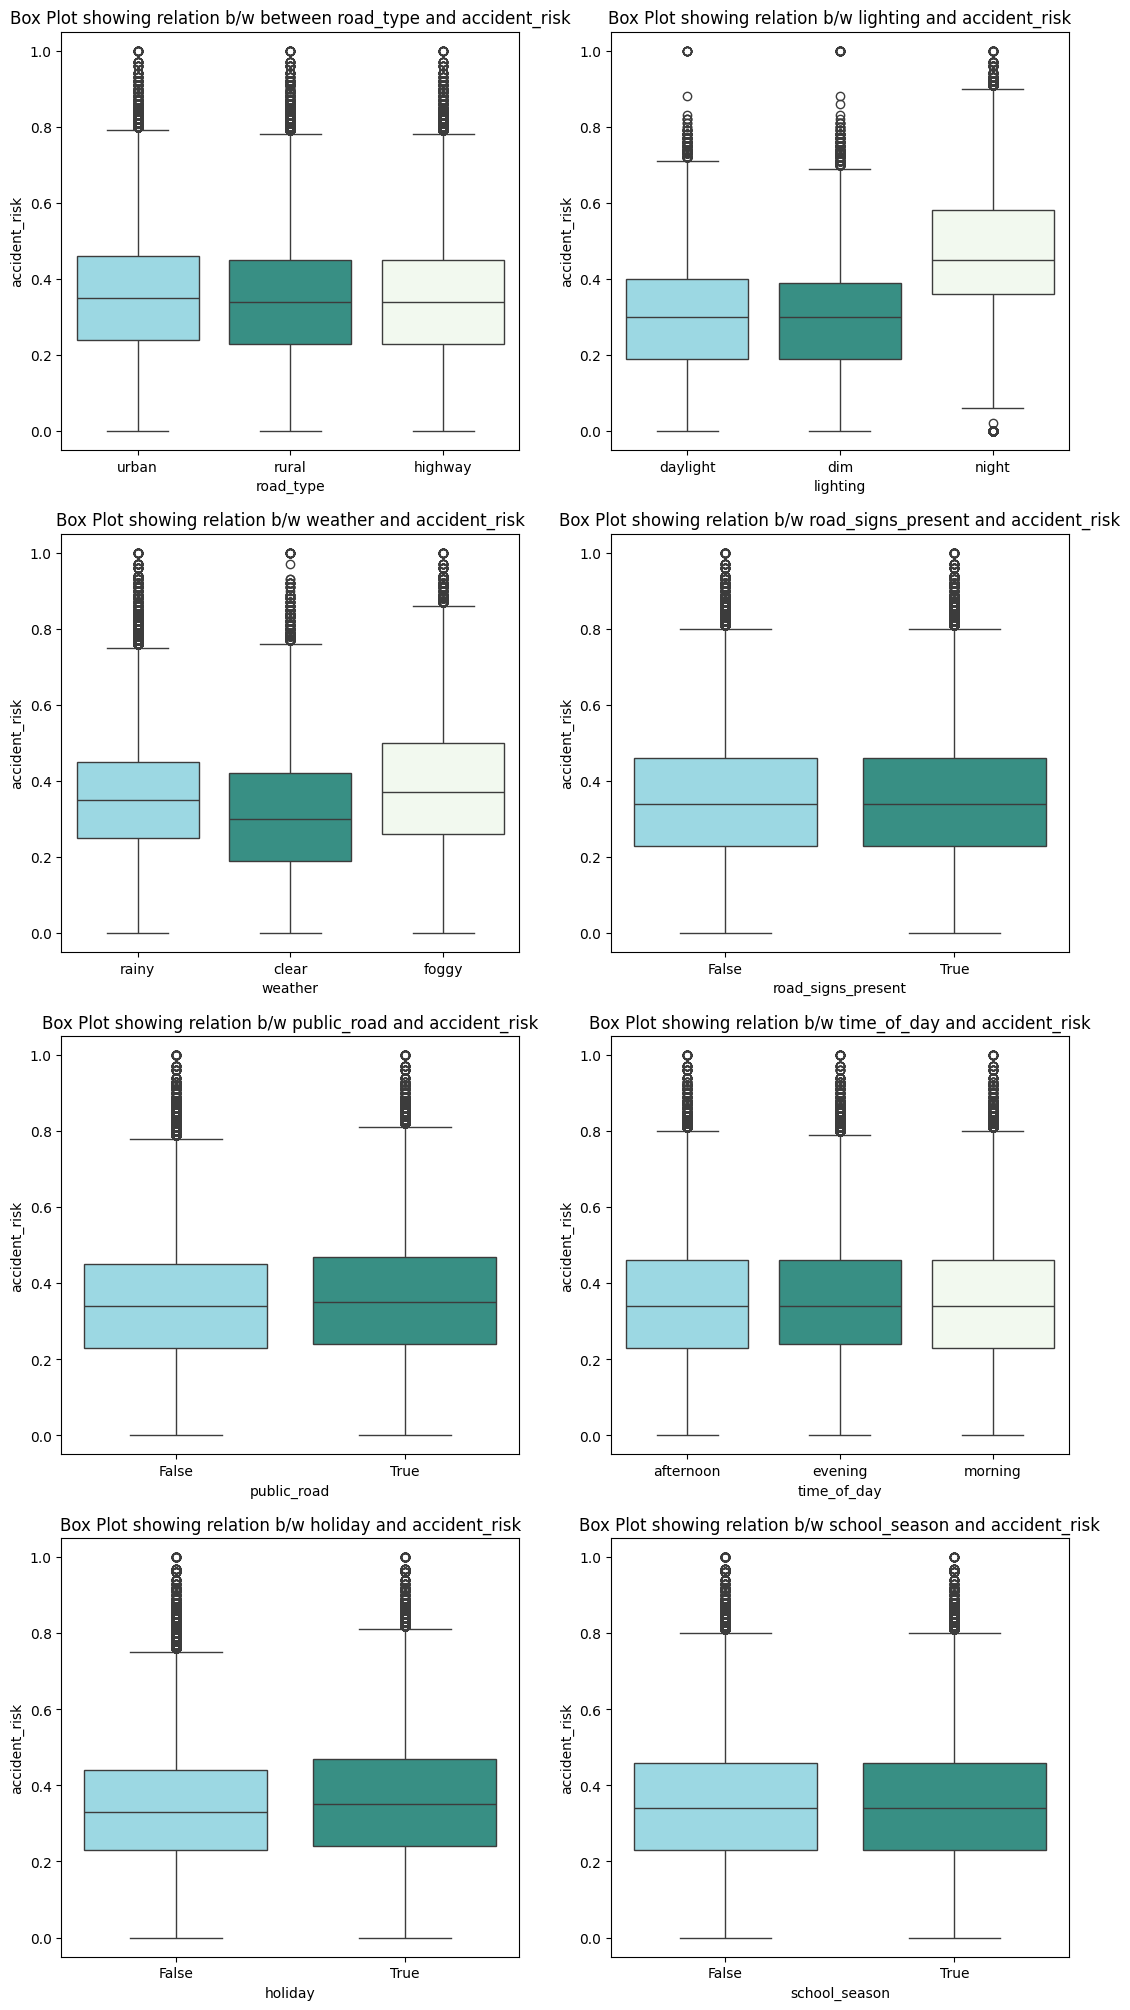

In [ ]:
# Categorical Columns
# Here box plot showing relation between a categorical feature and numerical target variable

#1B3A4B  (Deep Teal)
#2A9D8F  (Sea Green)
#4CC9F0  (Sky Blue)
#90E0EF  (Light Aqua)
#F1FAEE  (Soft Off-White)


fig,axes=plt.subplots(4,2,figsize=(13, 25))
sns.boxplot(data=df,x='road_type',y='accident_risk',ax=axes[0][0],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[0][0].set_title('Box Plot showing relation b/w between road_type and accident_risk')
sns.boxplot(data=df,x='lighting',y='accident_risk',ax=axes[0][1],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[0][1].set_title('Box Plot showing relation b/w lighting and accident_risk')
sns.boxplot(data=df,x='weather',y='accident_risk',ax=axes[1][0],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[1][0].set_title('Box Plot showing relation b/w weather and accident_risk')
sns.boxplot(data=df,x='road_signs_present',y='accident_risk',ax=axes[1][1],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[1][1].set_title('Box Plot showing relation b/w road_signs_present and accident_risk')
sns.boxplot(data=df,x='public_road',y='accident_risk',ax=axes[2][0],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[2][0].set_title('Box Plot showing relation b/w public_road and accident_risk')
sns.boxplot(data=df,x='time_of_day',y='accident_risk',ax=axes[2][1],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[2][1].set_title('Box Plot showing relation b/w time_of_day and accident_risk')
sns.boxplot(data=df,x='holiday',y='accident_risk',ax=axes[3][0],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[3][0].set_title('Box Plot showing relation b/w holiday and accident_risk')
sns.boxplot(data=df,x='school_season',y='accident_risk',ax=axes[3][1],palette=['#90E0EF','#2A9D8F','#F1FAEE'])
axes[3][1].set_title('Box Plot showing relation b/w school_season and accident_risk');

# multivariate

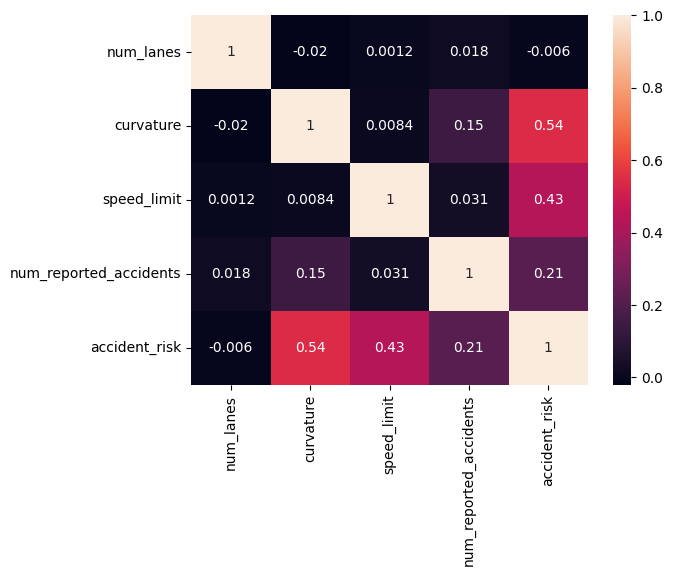

In [ ]:
sns.heatmap(num_cols.corr(),annot=True);

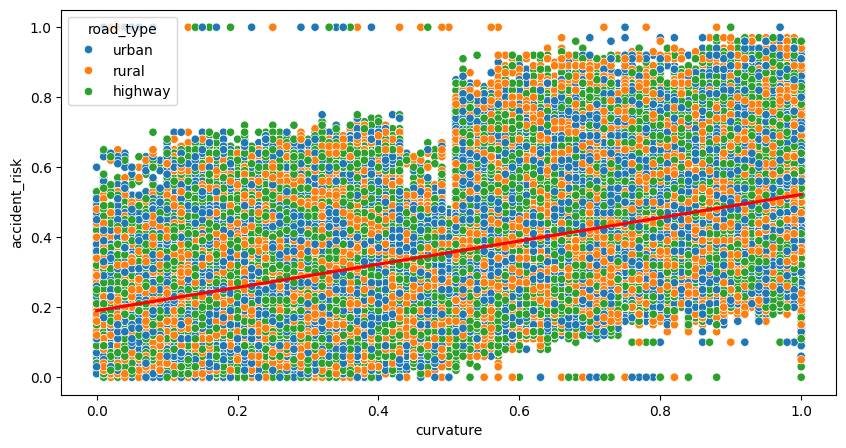

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(x=df['curvature'],y=df['accident_risk'],hue=df['road_type'])

sns.regplot(x=df['curvature'],y=df['accident_risk'],scatter=False,color='red',ci=None);


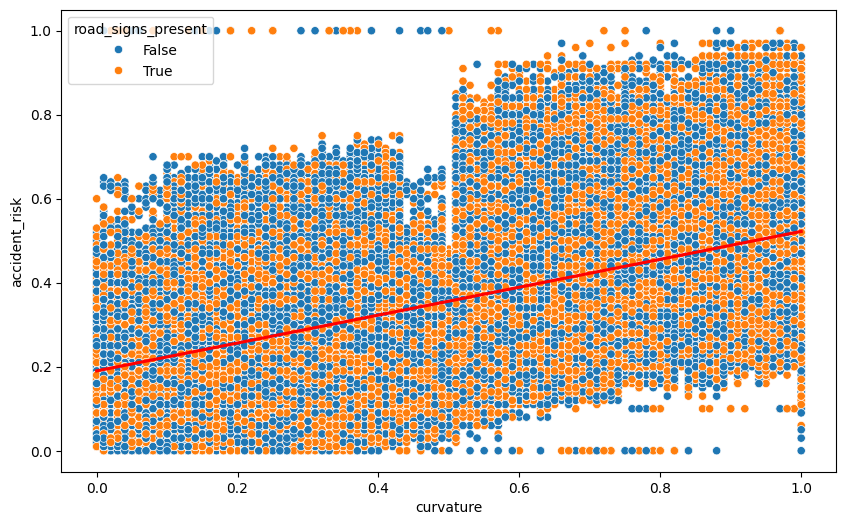

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=df['curvature'],y=df['accident_risk'],hue=df['road_signs_present'])

sns.regplot(x=df['curvature'],y=df['accident_risk'],scatter=False,color='red',ci=None);


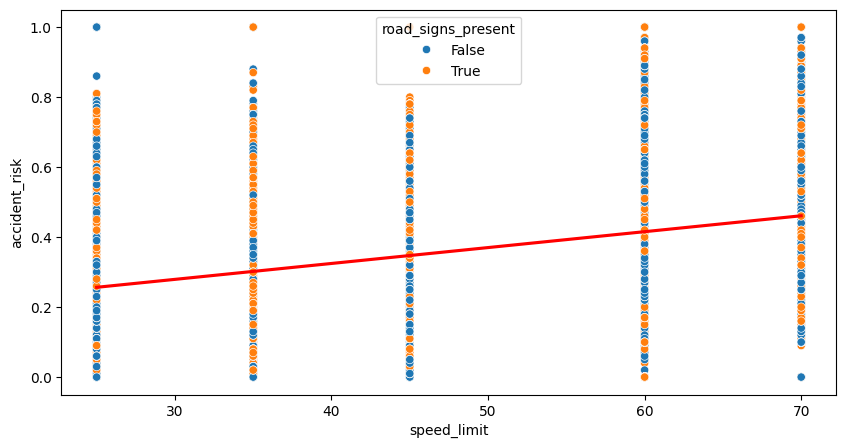

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(x=df['speed_limit'],y=df['accident_risk'],hue=df['road_signs_present'])

sns.regplot(x=df['speed_limit'],y=df['accident_risk'],scatter=False,color='red',ci=None);


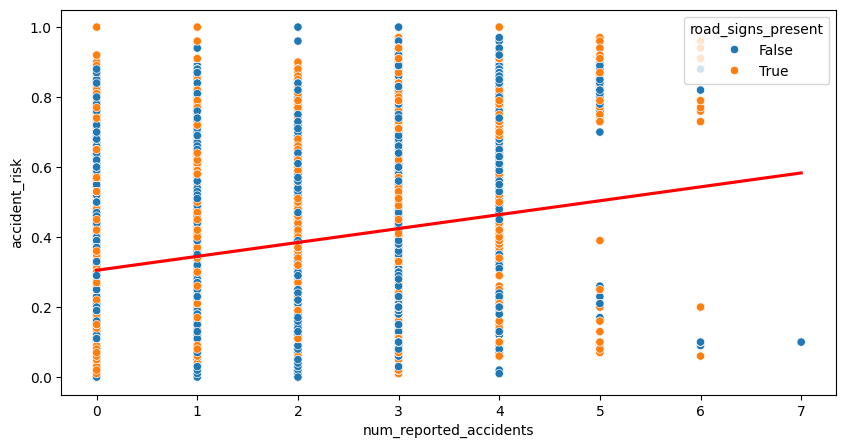

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(x=df['num_reported_accidents'],y=df['accident_risk'],hue=df['road_signs_present'])

sns.regplot(x=df['num_reported_accidents'],y=df['accident_risk'],scatter=False,color='red',ci=None);


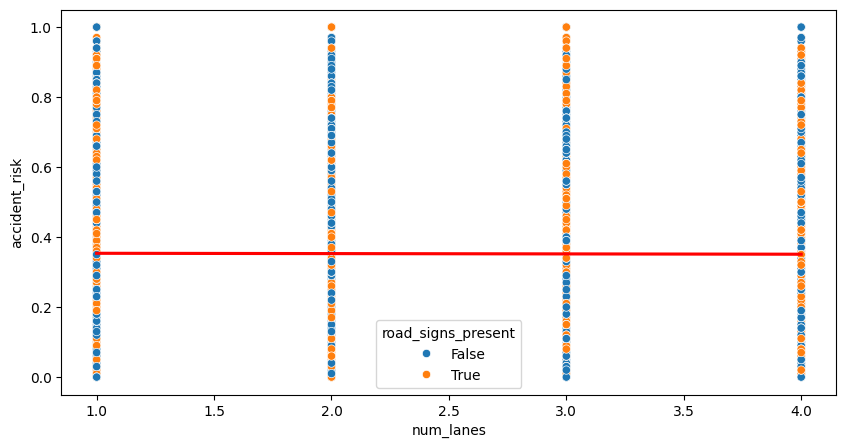

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(x=df['num_lanes'],y=df['accident_risk'],hue=df['road_signs_present'])

sns.regplot(x=df['num_lanes'],y=df['accident_risk'],scatter=False,color='red',ci=None);


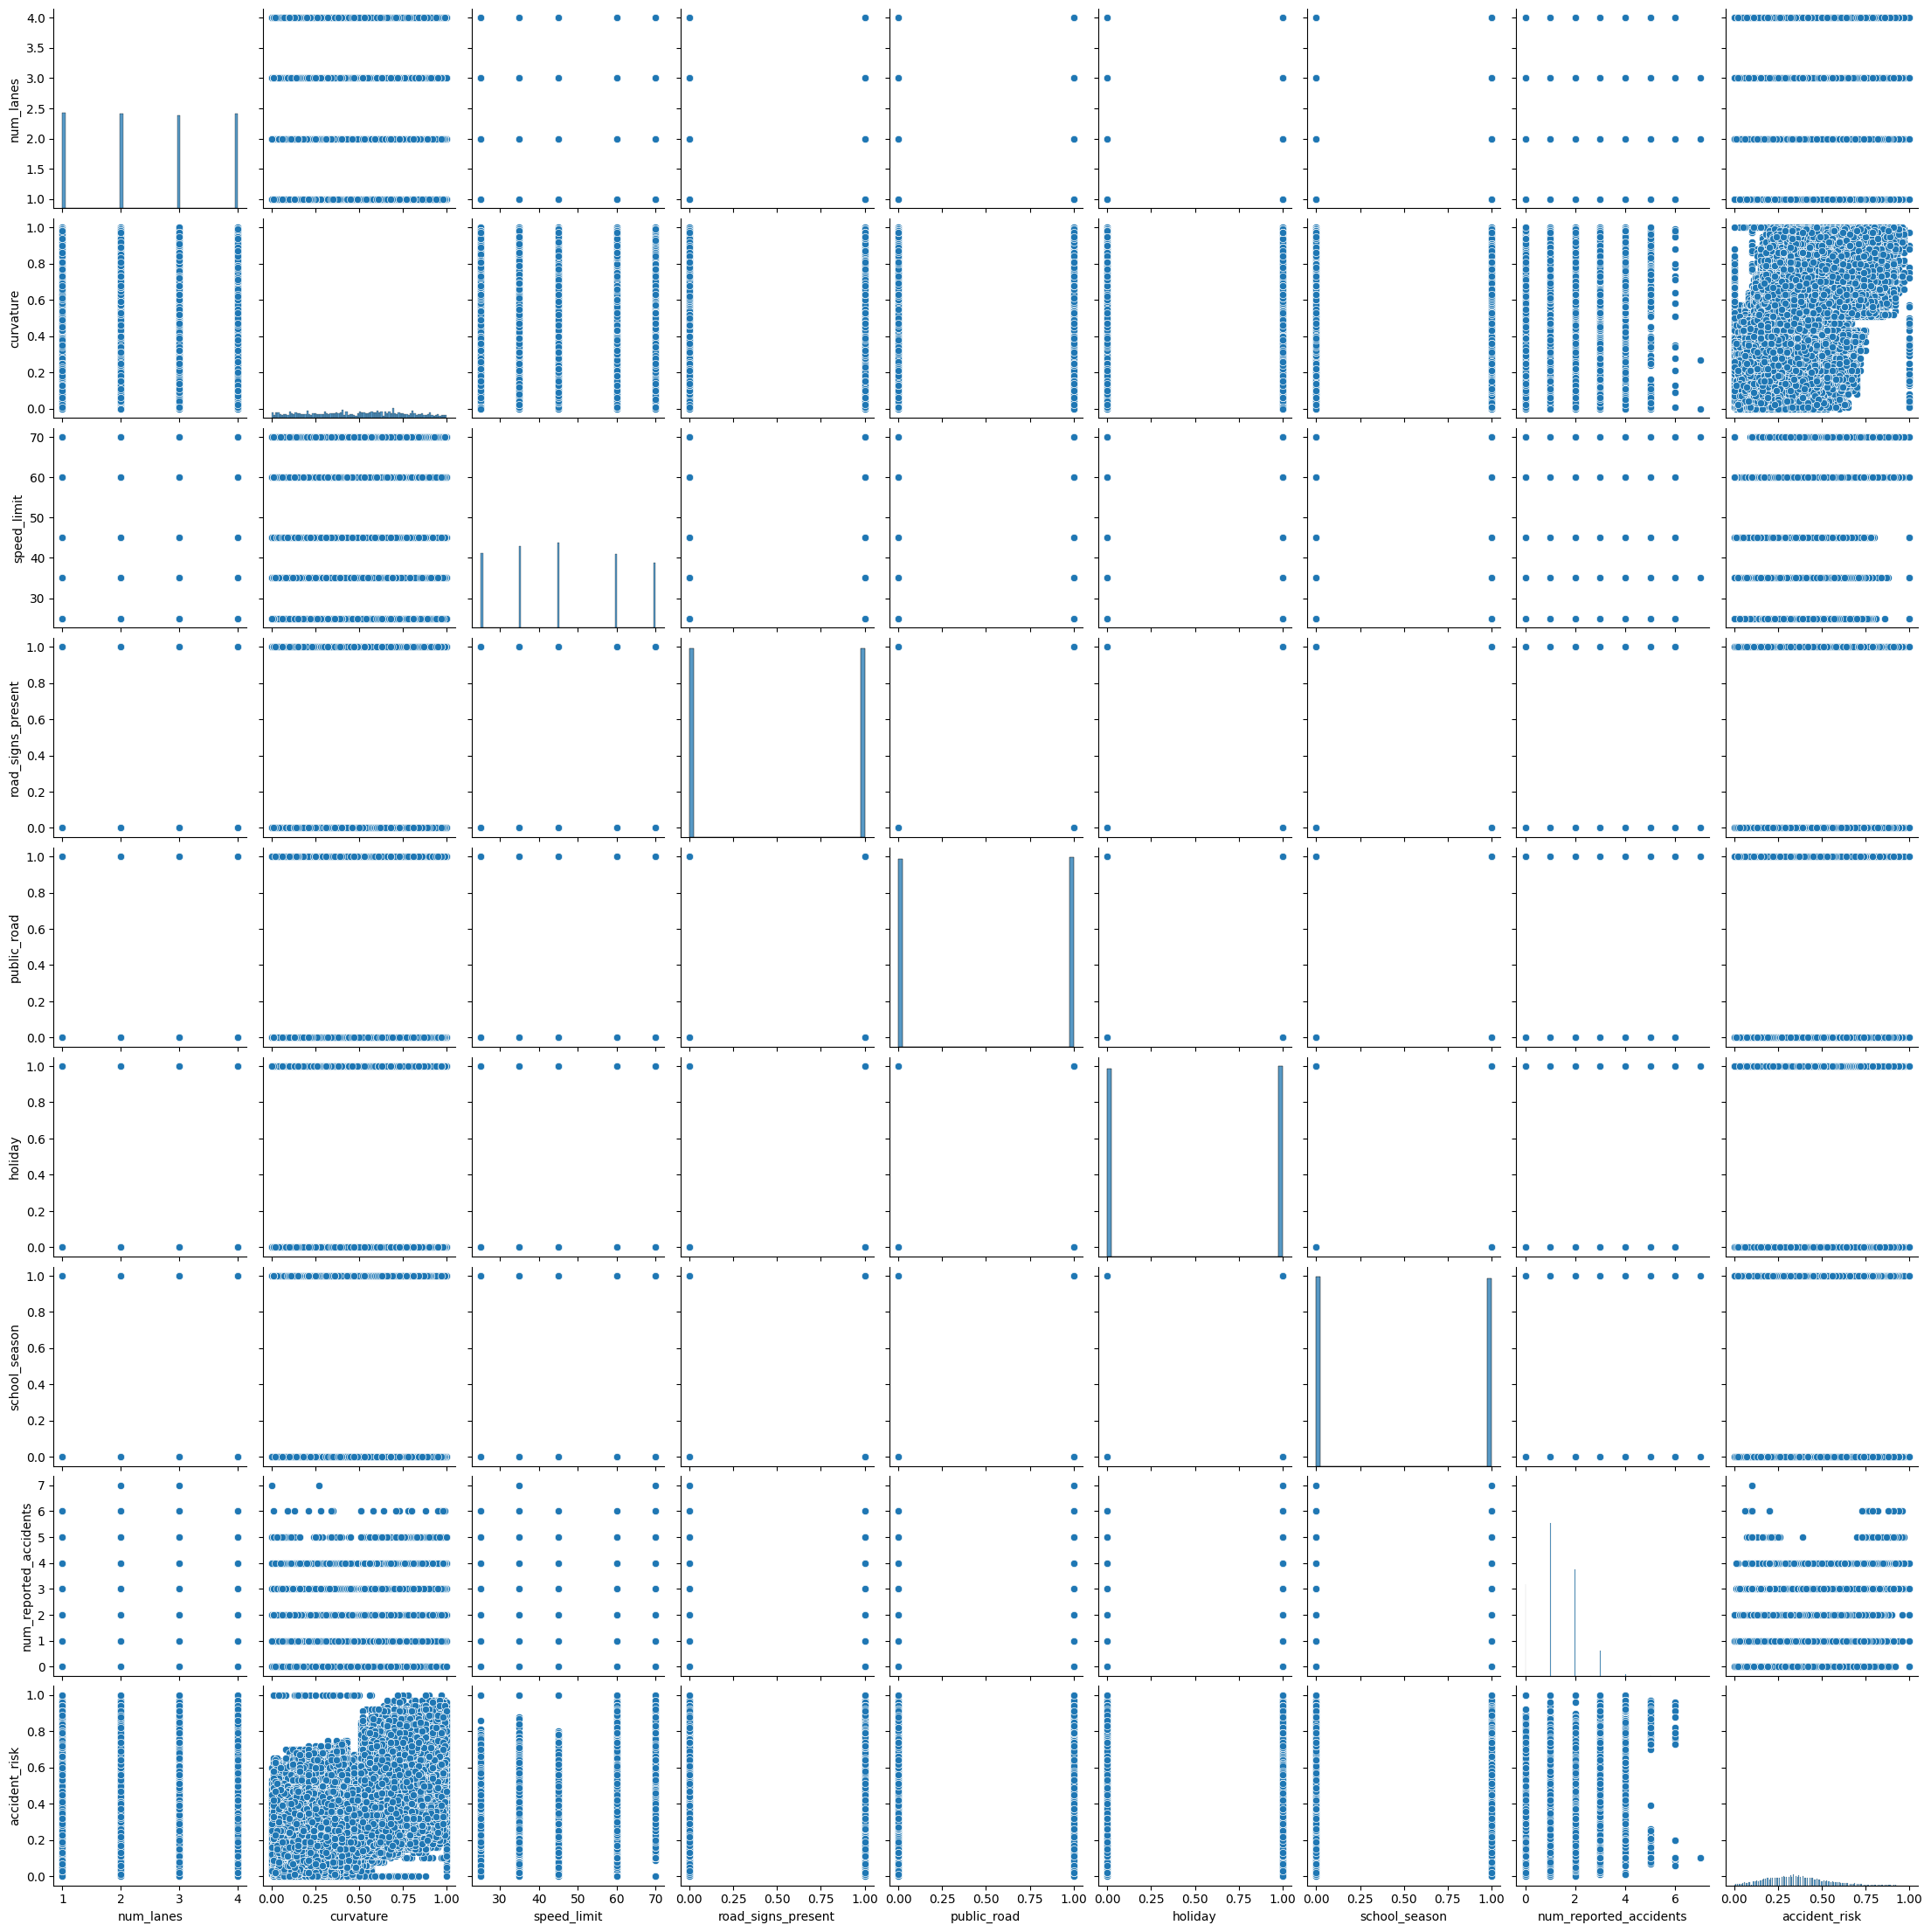

In [ ]:
sns.pairplot(df,palette=['#B56576']);

# **road_type=highway**

In [ ]:
round(df[df['road_type']=='highway']['curvature'].mean(),2)

np.float64(0.49)

In [ ]:

round(df[df['road_type']=='highway']['accident_risk'].mean(),2)

np.float64(0.35)

In [ ]:
round(df[df['road_type']=='highway']['speed_limit'].mean(),2)

np.float64(45.9)

In [ ]:
round(df[df['road_type']=='highway']['num_lanes'].mode(),2)

,num_lanes
0,1


In [ ]:
round(df[df['road_type']=='highway']['num_reported_accidents'].mode(),2)

,num_reported_accidents
0,1


In [ ]:
df['road_signs_present'].unique()

array([False,  True])

In [ ]:
df.head()
df.shape

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


(517754, 13)

In [ ]:
# case1 --> road_type=highway, lighting=daylight, weather=rainy,time_of_day=morning

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
799,highway,3,0.56,60,daylight,rainy,False,False,morning,True,True,2,0.51
860,highway,3,0.49,70,daylight,rainy,False,True,morning,False,False,1,0.47
1315,highway,1,0.75,60,daylight,rainy,False,True,morning,False,False,2,0.44
1358,highway,4,0.73,60,daylight,rainy,True,True,morning,True,False,3,0.60
1540,highway,1,0.63,60,daylight,rainy,False,True,morning,True,True,1,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513322,highway,2,0.68,60,daylight,rainy,False,True,morning,False,False,3,0.49
513708,highway,2,0.93,60,daylight,rainy,True,True,morning,False,True,3,0.74
513957,highway,1,0.86,60,daylight,rainy,True,False,morning,True,True,2,0.55
514551,highway,1,0.49,70,daylight,rainy,False,True,morning,False,False,2,0.48


np.float64(0.6878738738738739)

np.float64(0.5452612612612613)

np.float64(0.5272727272727271)

np.float64(0.5645945945945946)

np.float64(0.5224)

np.float64(0.5426470588235294)

**Key insights:-**

- Road signs consistently reduce accident risk

- School season :- With signs: 0.527, Without signs: 0.565, and Reduction ≈ 0.038
- Holiday season :- With signs: 0.52, Without signs: 0.565, and Reduction ≈ 0.021

In [ ]:
# case2 --> road_type=highway, lighting=daylight, weather=foggy,time_of_day=morning

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
29,highway,2,0.63,70,daylight,foggy,False,False,morning,False,False,1,0.41
820,highway,3,0.58,70,daylight,foggy,True,False,morning,True,True,3,0.57
2434,highway,4,0.62,70,daylight,foggy,True,False,morning,True,False,2,0.39
3028,highway,3,0.76,60,daylight,foggy,False,False,morning,True,True,2,0.57
3185,highway,3,0.83,70,daylight,foggy,True,False,morning,False,False,2,0.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515528,highway,2,0.84,70,daylight,foggy,False,False,morning,True,True,1,0.61
516336,highway,3,0.93,60,daylight,foggy,True,True,morning,True,True,1,0.56
516615,highway,1,0.75,70,daylight,foggy,True,True,morning,True,True,3,0.56
516874,highway,1,0.62,60,daylight,foggy,False,False,morning,True,True,1,0.58


np.float64(0.7165132743362833)

np.float64(0.5267964601769911)

np.float64(0.5224050632911392)

np.float64(0.5263157894736841)

np.float64(0.532051282051282)

np.float64(0.5277922077922077)

**Key insights:-**

- In foggy highway conditions, poor visibility is the main cause of accidents, while road signs and seasonal traffic have little impact.

In [ ]:
# case3 --> road_type=highway, lighting=daylight, weather=clear,time_of_day=morning

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
302,highway,2,0.61,60,daylight,clear,True,False,morning,True,True,1,0.39
325,highway,3,0.78,70,daylight,clear,True,True,morning,True,True,1,0.44
2082,highway,4,0.78,60,daylight,clear,True,False,morning,False,True,1,0.52
2174,highway,1,0.93,70,daylight,clear,False,True,morning,True,True,1,0.54
2992,highway,2,0.89,60,daylight,clear,False,True,morning,True,False,1,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515710,highway,1,0.59,60,daylight,clear,False,True,morning,False,False,1,0.47
515920,highway,3,0.62,60,daylight,clear,True,False,morning,True,False,1,0.36
516531,highway,1,0.51,60,daylight,clear,True,False,morning,False,True,2,0.38
517312,highway,4,0.86,70,daylight,clear,True,False,morning,False,True,4,0.50


np.float64(0.7481243830207305)

np.float64(0.4481934846989142)

np.float64(0.44171875000000005)

np.float64(0.445)

np.float64(0.4588405797101449)

np.float64(0.44461538461538463)

**Key insights:-**

- In clear highway conditions, accident risk is lowest and largely unaffected by road signs or seasonal traffic.

In [ ]:
# case4 --> road_type=highway, lighting=dim, weather=foggy,time_of_day=morning

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
584,highway,2,0.70,60,dim,foggy,False,False,morning,True,False,3,0.62
944,highway,2,0.57,70,dim,foggy,False,False,morning,True,False,2,0.52
1253,highway,1,0.81,70,dim,foggy,True,False,morning,True,False,2,0.47
1610,highway,2,0.85,60,dim,foggy,True,True,morning,False,False,2,0.61
2193,highway,4,0.98,70,dim,foggy,True,False,morning,False,False,3,0.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516306,highway,1,0.68,60,dim,foggy,True,False,morning,False,False,1,0.63
516829,highway,2,0.83,70,dim,foggy,True,True,morning,False,False,2,0.56
517062,highway,2,0.79,70,dim,foggy,True,True,morning,False,False,1,0.62
517267,highway,4,0.92,60,dim,foggy,True,False,morning,True,True,2,0.60


np.float64(0.7265526552655266)

np.float64(0.5314401440144015)

np.float64(0.5353424657534247)

np.float64(0.5326666666666667)

np.float64(0.5361842105263159)

np.float64(0.5422619047619048)

**Key insights:-**


- When fog is combined with dim lighting on highways, accident risk is highest and road signs provide little protection.

In [ ]:
# case5 --> road_type=highway, lighting=dim, weather=rainy,time_of_day=morning

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()



,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
1352,highway,3,0.59,60,dim,rainy,True,False,morning,True,True,2,0.49
1771,highway,3,0.51,70,dim,rainy,True,False,morning,False,True,1,0.49
2448,highway,3,0.71,60,dim,rainy,False,False,morning,True,False,2,0.45
4307,highway,1,0.76,60,dim,rainy,False,False,morning,False,True,1,0.59
4991,highway,4,0.87,60,dim,rainy,False,True,morning,True,False,1,0.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516796,highway,4,0.72,60,dim,rainy,True,True,morning,False,True,2,0.49
516864,highway,1,0.63,60,dim,rainy,False,False,morning,True,False,2,0.39
516897,highway,2,0.98,60,dim,rainy,True,True,morning,True,False,2,0.57
517186,highway,1,0.86,60,dim,rainy,False,False,morning,True,False,2,0.64


np.float64(0.6859113300492611)

np.float64(0.5329064039408866)

np.float64(0.5407500000000001)

np.float64(0.5084782608695652)

np.float64(0.5315217391304349)

np.float64(0.5384090909090911)

**Key insights:-**

- In rainy, dim highway conditions, accident risk is high, but the effect of road signs is inconsistent, indicating driver behavior strongly influences outcomes under poor visibility.

In [ ]:
# case6 -->  road_type=highway, lighting=daylight, weather=rainy,time_of_day=afternoon

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
1478,highway,1,0.81,60,daylight,rainy,False,True,afternoon,True,False,3,0.69
3199,highway,3,0.66,70,daylight,rainy,False,False,afternoon,True,True,3,0.66
3215,highway,3,0.91,60,daylight,rainy,True,True,afternoon,True,False,3,0.67
3220,highway,1,0.56,60,daylight,rainy,False,False,afternoon,True,False,2,0.37
4820,highway,2,0.51,60,daylight,rainy,True,False,afternoon,True,False,3,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...
509707,highway,2,0.77,60,daylight,rainy,False,True,afternoon,True,False,1,0.42
511082,highway,4,0.51,60,daylight,rainy,True,False,afternoon,False,True,1,0.42
512302,highway,4,0.66,60,daylight,rainy,True,True,afternoon,False,False,2,0.46
514287,highway,3,0.79,60,daylight,rainy,False,True,afternoon,True,True,1,0.58


np.float64(0.6788372093023256)

np.float64(0.537227191413238)

np.float64(0.5187179487179486)

np.float64(0.5396)

np.float64(0.5572)

np.float64(0.5237209302325582)

**Key insights:-**

- On rainy highways in the afternoon, accident risk is high; road signs help inconsistently, and holiday traffic is slightly riskier than school-season traffic

In [ ]:
# case7 -->  road_type=highway, lighting=daylight, weather=foggy,time_of_day=afternoon

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()



,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
278,highway,2,0.57,70,daylight,foggy,True,False,afternoon,True,True,1,0.47
424,highway,4,0.82,70,daylight,foggy,False,True,afternoon,True,True,3,0.56
880,highway,2,0.81,60,daylight,foggy,False,False,afternoon,True,False,1,0.52
1865,highway,4,0.68,70,daylight,foggy,True,True,afternoon,True,False,1,0.63
2225,highway,4,0.56,60,daylight,foggy,True,True,afternoon,True,True,1,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515215,highway,4,0.76,70,daylight,foggy,False,False,afternoon,False,True,3,0.68
516063,highway,2,0.58,60,daylight,foggy,False,True,afternoon,False,True,2,0.53
516140,highway,4,0.53,70,daylight,foggy,False,False,afternoon,False,True,2,0.49
516487,highway,3,0.87,70,daylight,foggy,True,True,afternoon,True,False,3,0.71


np.float64(0.7133587786259542)

np.float64(0.528863443596268)

np.float64(0.5347692307692308)

np.float64(0.5141558441558441)

np.float64(0.5312162162162163)

np.float64(0.5319512195121952)

**Key insights:-**

- On foggy highways in the afternoon, accident risk stays high; road signs help moderately, and holiday traffic shows only minor variations

In [ ]:
# case8 -->  road_type=highway, lighting=daylight, weather=foggy,time_of_day=afternoon

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
228,highway,4,0.56,60,daylight,clear,False,True,afternoon,False,False,1,0.41
476,highway,2,0.52,60,daylight,clear,True,False,afternoon,True,True,1,0.35
496,highway,4,0.57,60,daylight,clear,True,False,afternoon,True,True,3,0.48
590,highway,4,0.88,60,daylight,clear,True,True,afternoon,True,False,3,0.56
1856,highway,1,0.99,60,daylight,clear,True,True,afternoon,True,False,1,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515465,highway,3,0.60,70,daylight,clear,True,True,afternoon,True,False,3,0.45
516438,highway,1,0.66,70,daylight,clear,True,False,afternoon,False,False,1,0.43
516495,highway,4,0.81,70,daylight,clear,False,False,afternoon,False,True,3,0.46
516792,highway,2,0.97,70,daylight,clear,False,True,afternoon,True,True,1,0.44


np.float64(0.7406828811973807)

np.float64(0.452488306828812)

np.float64(0.4441935483870968)

np.float64(0.44736842105263147)

np.float64(0.45250000000000007)

np.float64(0.4613846153846154)

**Key insights:-**

- Accident risk is highest on holidays and increases further when road signs are absent.

- Even under ideal conditions (daylight, clear weather, highways), holidays raise accident risk, and road signs consistently reduce it—especially during holidays.


In [ ]:
# case9 -->  road_type=highway, lighting=daylight, weather=foggy,time_of_day=afternoon

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
1350,highway,3,0.65,60,dim,clear,True,True,afternoon,True,True,1,0.39
1580,highway,2,0.82,60,dim,clear,False,True,afternoon,False,False,2,0.45
1688,highway,4,0.75,60,dim,clear,False,True,afternoon,False,True,2,0.36
2013,highway,1,0.64,70,dim,clear,True,True,afternoon,False,True,2,0.39
2100,highway,2,0.67,70,dim,clear,False,True,afternoon,False,True,1,0.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514934,highway,2,0.59,60,dim,clear,True,True,afternoon,False,False,1,0.36
516257,highway,1,0.49,70,dim,clear,False,True,afternoon,False,True,1,0.36
516973,highway,4,0.60,60,dim,clear,False,True,afternoon,False,True,1,0.51
517141,highway,3,0.65,70,dim,clear,True,True,afternoon,True,True,1,0.35


np.float64(0.7459262948207173)

np.float64(0.45285856573705174)

np.float64(0.4593055555555556)

np.float64(0.4525714285714286)

np.float64(0.45714285714285713)

np.float64(0.4613043478260869)

**Key insights:-**

- Dim lighting keeps accident risk high, and holidays make it even worse—road signs help less in these conditions.

In [ ]:
# case10 -->  road_type=highway, lighting=daylight, weather=clear,time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
163,highway,2,0.79,70,daylight,clear,True,False,evening,True,True,3,0.54
1378,highway,3,0.85,60,daylight,clear,False,False,evening,True,True,1,0.51
1422,highway,2,0.73,60,daylight,clear,False,True,evening,True,True,2,0.43
1532,highway,1,0.85,60,daylight,clear,False,False,evening,True,True,1,0.53
1903,highway,3,0.97,60,daylight,clear,True,True,evening,True,True,1,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515275,highway,3,0.70,70,daylight,clear,False,True,evening,True,False,1,0.41
516153,highway,4,0.95,60,daylight,clear,False,True,evening,True,True,1,0.45
516255,highway,1,0.65,60,daylight,clear,True,True,evening,True,True,2,0.39
517111,highway,2,0.81,70,daylight,clear,True,False,evening,True,False,2,0.52


np.float64(0.745542521994135)

np.float64(0.45195503421309874)

np.float64(0.43895522388059705)

np.float64(0.4520588235294118)

np.float64(0.47363636363636363)

np.float64(0.45325000000000004)

**Key insights:-**

- Evening driving shows higher accident risk on holidays, and missing road signs generally increase risk—especially on non-holidays.

In [ ]:
# case11 -->  road_type=highway, lighting=daylight, weather=foggy,time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
25,highway,1,0.49,70,daylight,foggy,True,True,evening,False,False,1,0.40
329,highway,4,0.92,60,daylight,foggy,True,False,evening,True,False,1,0.62
447,highway,4,0.55,60,daylight,foggy,False,True,evening,True,False,2,0.43
1652,highway,2,0.99,60,daylight,foggy,False,False,evening,True,False,2,0.48
1730,highway,2,0.53,60,daylight,foggy,True,True,evening,True,False,1,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517089,highway,4,0.60,60,daylight,foggy,True,True,evening,False,True,2,0.64
517181,highway,3,0.77,60,daylight,foggy,True,False,evening,True,False,1,0.60
517257,highway,2,0.70,60,daylight,foggy,False,False,evening,True,True,1,0.52
517340,highway,1,0.75,60,daylight,foggy,False,False,evening,False,True,2,0.52


np.float64(0.7153529937444146)

np.float64(0.5286237712243074)

np.float64(0.5242666666666668)

np.float64(0.532923076923077)

np.float64(0.5310204081632653)

np.float64(0.5234567901234568)

**Key insights:-**

- Foggy evening conditions drive accident risk very high, with little difference from road signs—holidays keep risk elevated but don’t change the pattern much.

In [ ]:
# case12 -->  road_type=highway, lighting=daylight, weather=rainy,time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
2555,highway,2,0.49,60,daylight,rainy,True,False,evening,True,True,1,0.49
3715,highway,4,0.59,60,daylight,rainy,False,True,evening,True,True,1,0.48
4202,highway,3,0.87,60,daylight,rainy,False,True,evening,True,False,1,0.50
5486,highway,3,0.68,70,daylight,rainy,True,False,evening,True,True,3,0.57
6834,highway,2,0.67,60,daylight,rainy,False,True,evening,False,True,1,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513895,highway,1,0.85,60,daylight,rainy,False,True,evening,True,False,1,0.62
514072,highway,1,0.70,60,daylight,rainy,True,True,evening,False,False,2,0.45
515017,highway,2,0.77,60,daylight,rainy,False,True,evening,True,True,2,0.53
515112,highway,4,0.49,70,daylight,rainy,False,True,evening,False,True,2,0.48


np.float64(0.6839042357274402)

np.float64(0.5372375690607736)

np.float64(0.5233333333333333)

np.float64(0.5346666666666666)

np.float64(0.5199999999999999)

np.float64(0.522909090909091)

**Key insights:-**

- Rainy evenings keep accident risk very high, and missing road signs slightly worsen risk—holiday effects are present but relatively small compared to weather.

In [ ]:
# case13 -->  road_type=highway, lighting=dim, weather=rainy, time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
290,highway,1,0.88,60,dim,rainy,False,False,evening,False,True,3,0.69
445,highway,4,0.63,60,dim,rainy,False,False,evening,True,False,2,0.50
836,highway,4,0.53,60,dim,rainy,True,True,evening,False,True,2,0.51
1152,highway,1,0.68,60,dim,rainy,False,True,evening,False,False,2,0.46
2157,highway,3,0.74,60,dim,rainy,False,False,evening,True,True,1,0.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512955,highway,1,0.86,60,dim,rainy,False,False,evening,True,False,2,0.57
513514,highway,4,0.62,60,dim,rainy,True,True,evening,False,False,1,0.48
514341,highway,4,0.69,60,dim,rainy,False,True,evening,True,False,2,0.53
514399,highway,1,0.52,70,dim,rainy,True,False,evening,False,True,3,0.58


np.float64(0.6983797909407665)

np.float64(0.5409233449477352)

np.float64(0.525609756097561)

np.float64(0.5793939393939394)

np.float64(0.5248648648648649)

np.float64(0.5382926829268293)

**Key insights:-**

- Dim lighting plus rain creates the highest accident risk—missing road signs makes it even worse, especially on non-holidays.

In [ ]:
# case14 -->  road_type=highway, lighting=dim, weather=foggy, time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
978,highway,3,0.76,70,dim,foggy,False,True,evening,True,False,1,0.53
1272,highway,4,0.52,60,dim,foggy,True,False,evening,False,True,1,0.45
1823,highway,1,0.58,70,dim,foggy,False,True,evening,False,False,1,0.51
2003,highway,1,0.51,60,dim,foggy,False,True,evening,False,False,1,0.46
2061,highway,1,0.68,70,dim,foggy,False,True,evening,True,False,2,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514773,highway,1,0.82,70,dim,foggy,False,True,evening,False,False,2,0.53
515242,highway,4,0.65,60,dim,foggy,True,False,evening,False,False,1,0.52
516100,highway,3,0.89,70,dim,foggy,True,True,evening,False,True,3,0.61
516612,highway,1,0.60,60,dim,foggy,True,True,evening,False,False,1,0.54


np.float64(0.7233635539437897)

np.float64(0.5292112420670898)

np.float64(0.5352459016393443)

np.float64(0.5278947368421053)

np.float64(0.5349333333333334)

np.float64(0.5304054054054055)

**Key insights:-**

- Dim, foggy evenings keep accident risk extremely high, and road signs or holidays make little difference—the conditions themselves dominate.

In [ ]:
# case15 -->  road_type=highway, lighting=dim, weather=clear, time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
262,highway,3,0.58,70,dim,clear,False,True,evening,False,False,1,0.39
1068,highway,3,0.79,60,dim,clear,False,False,evening,True,True,3,0.58
1301,highway,2,0.78,70,dim,clear,False,False,evening,True,True,3,0.52
1763,highway,3,0.68,60,dim,clear,True,False,evening,True,True,2,0.36
1981,highway,2,0.89,60,dim,clear,True,False,evening,False,True,3,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516023,highway,2,0.62,60,dim,clear,True,True,evening,True,False,1,0.36
516634,highway,3,0.86,70,dim,clear,False,False,evening,True,False,3,0.55
517189,highway,2,0.72,60,dim,clear,True,False,evening,False,False,2,0.44
517389,highway,1,0.85,60,dim,clear,False,False,evening,False,False,2,0.47


np.float64(0.7415684210526315)

np.float64(0.45050526315789474)

np.float64(0.4439285714285714)

np.float64(0.4566666666666666)

np.float64(0.4611290322580645)

np.float64(0.4487142857142858)

**Key insights:-**

- In dim but clear evenings, accident risk rises on holidays and is slightly higher when road signs are missing.

In [ ]:
# case16 -->  road_type=highway, lighting=night, weather=clear, time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
19,highway,2,0.86,70,night,clear,False,False,evening,False,False,3,0.79
240,highway,1,0.55,60,night,clear,True,True,evening,True,True,1,0.52
792,highway,4,0.49,60,night,clear,False,True,evening,False,True,1,0.49
913,highway,4,0.57,70,night,clear,False,True,evening,True,True,1,0.43
1075,highway,1,0.53,60,night,clear,True,True,evening,False,False,2,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515423,highway,1,0.80,60,night,clear,False,False,evening,False,True,2,0.58
515719,highway,3,0.68,60,night,clear,True,True,evening,True,False,3,0.74
516334,highway,2,0.55,70,night,clear,False,False,evening,False,True,1,0.69
517265,highway,2,0.76,70,night,clear,False,False,evening,True,False,1,0.67


np.float64(0.7023967611336033)

np.float64(0.6233441295546558)

np.float64(0.6311392405063292)

np.float64(0.6155384615384615)

np.float64(0.6207865168539326)

np.float64(0.6219148936170212)

**Key insights:-**

- Nighttime driving on highways is very risky—accident risk is highest overall, and missing road signs or holidays make only small differences.

In [ ]:
# case17 -->  road_type=highway, lighting=night, weather=clear, time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
101,highway,4,0.90,60,night,rainy,False,False,evening,True,False,4,0.84
315,highway,4,0.73,60,night,rainy,False,True,evening,True,False,3,0.92
1127,highway,2,0.62,60,night,rainy,False,True,evening,False,True,2,0.73
1182,highway,2,0.62,70,night,rainy,False,False,evening,True,True,5,0.79
2518,highway,2,0.62,60,night,rainy,False,False,evening,True,False,4,0.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...
509682,highway,1,0.56,70,night,rainy,False,True,evening,True,False,1,0.58
510828,highway,2,0.70,60,night,rainy,True,True,evening,True,False,2,0.80
511152,highway,4,0.75,60,night,rainy,True,True,evening,False,True,3,0.79
513167,highway,3,0.96,60,night,rainy,True,True,evening,True,False,1,0.78


np.float64(0.7006238532110092)

np.float64(0.7329724770642202)

np.float64(0.738857142857143)

np.float64(0.7185185185185186)

np.float64(0.7399999999999999)

np.float64(0.7169565217391305)

**Key insights:-**

- Nighttime rain on highways is extremely dangerous—accident risk soars above all other conditions, and missing road signs or holidays slightly reduce or increase it, but the weather and darkness dominate.

In [ ]:
# case18 -->  road_type=highway, lighting=night, weather=clear, time_of_day=evening

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False)&(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='highway')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=45.9)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True)&(df['school_season']==False)]['accident_risk'].mean()




,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
146,highway,4,0.66,70,night,foggy,False,False,evening,True,True,2,0.77
152,highway,4,0.83,60,night,foggy,False,False,evening,False,False,1,0.68
178,highway,2,0.83,70,night,foggy,False,True,evening,False,True,4,0.80
202,highway,4,0.59,60,night,foggy,True,False,evening,False,True,2,0.64
855,highway,2,0.67,70,night,foggy,False,True,evening,True,False,1,0.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517190,highway,4,0.53,70,night,foggy,False,True,evening,False,True,1,0.67
517381,highway,3,0.76,70,night,foggy,False,False,evening,True,False,1,0.76
517384,highway,1,0.66,70,night,foggy,False,False,evening,True,True,1,0.66
517646,highway,4,0.60,60,night,foggy,True,False,evening,False,False,1,0.72


np.float64(0.7034160305343512)

np.float64(0.7163358778625954)

np.float64(0.7064102564102565)

np.float64(0.6938709677419356)

np.float64(0.7095945945945946)

np.float64(0.7212857142857143)

**Key insights:-**

- Nighttime fog on highways keeps accident risk extremely high. Missing road signs and holidays can slightly increase or decrease it, but the dark, foggy conditions are the main danger.

# **road_type=urban**

In [ ]:
round(df[df['road_type']=='urban']['curvature'].mean(),2)

np.float64(0.49)

In [ ]:
round(df[df['road_type']=='urban']['accident_risk'].mean(),2)

np.float64(0.36)

In [ ]:
round(df[df['road_type']=='urban']['speed_limit'].mean(),2)

np.float64(46.3)

In [ ]:
round(df[df['road_type']=='urban']['num_lanes'].mode(),2)

,num_lanes
0,1


In [ ]:
round(df[df['road_type']=='urban']['num_reported_accidents'].mode(),2)

,num_reported_accidents
0,1


In [ ]:
# case: 1 --> road_type=urban, lighting=daylight, weather=rainy,time_of_day=morning

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
121,urban,2,0.65,60,daylight,rainy,False,True,morning,True,True,1,0.54
2160,urban,1,0.75,60,daylight,rainy,False,False,morning,True,True,2,0.55
2953,urban,4,0.51,60,daylight,rainy,False,False,morning,False,False,1,0.43
4197,urban,3,0.68,60,daylight,rainy,True,False,morning,True,False,2,0.44
5969,urban,1,0.76,60,daylight,rainy,True,True,morning,True,True,2,0.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515155,urban,2,0.68,60,daylight,rainy,True,False,morning,False,False,2,0.46
515365,urban,1,0.52,70,daylight,rainy,True,True,morning,False,False,2,0.39
516170,urban,3,0.67,60,daylight,rainy,False,True,morning,True,True,1,0.45
516856,urban,4,0.54,70,daylight,rainy,True,True,morning,True,True,3,0.54


np.float64(0.68552)

np.float64(0.542592)

np.float64(0.5384444444444443)

np.float64(0.5424324324324326)

np.float64(0.5146341463414633)

np.float64(0.539)

**Key insights:-**

- Rainy mornings in urban areas carry high accident risk. Road signs slightly reduce risk, but holidays don’t always increase it—risk patterns depend more on weather and time of day.

In [ ]:
# case2 --> road_type=urban, lighting=daylight, weather=foggy,time_of_day=morning

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
196,urban,1,0.65,70,daylight,foggy,True,False,morning,False,False,1,0.50
603,urban,2,0.68,70,daylight,foggy,False,True,morning,False,True,1,0.44
928,urban,1,0.86,60,daylight,foggy,True,False,morning,True,False,1,0.53
951,urban,2,0.88,70,daylight,foggy,False,True,morning,True,False,2,0.55
1334,urban,1,0.65,70,daylight,foggy,False,False,morning,True,True,2,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515683,urban,4,0.84,70,daylight,foggy,True,False,morning,True,False,1,0.55
516668,urban,1,0.94,60,daylight,foggy,True,True,morning,False,True,2,0.61
517051,urban,2,0.91,60,daylight,foggy,True,True,morning,True,False,3,0.71
517143,urban,3,0.73,70,daylight,foggy,True,False,morning,False,True,1,0.50


np.float64(0.7229541595925297)

np.float64(0.5278777589134125)

np.float64(0.5326315789473685)

np.float64(0.5352631578947369)

np.float64(0.5320731707317072)

np.float64(0.5348314606741573)

**Key insights:-**

- Foggy mornings in urban areas have consistently high accident risk. Road signs and holidays make very little difference—fog is the main factor.

In [ ]:
# case3 --> road_type=urban, lighting=daylight, weather=clear,time_of_day=morning

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
577,urban,1,0.74,70,daylight,clear,True,True,morning,False,False,3,0.60
1186,urban,4,0.67,70,daylight,clear,False,True,morning,True,False,1,0.41
1348,urban,1,0.67,60,daylight,clear,True,True,morning,False,False,3,0.56
1989,urban,2,0.79,60,daylight,clear,True,True,morning,False,False,1,0.38
2502,urban,2,0.57,70,daylight,clear,True,True,morning,False,True,2,0.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514078,urban,3,0.99,60,daylight,clear,False,True,morning,False,True,3,0.54
514527,urban,1,0.69,60,daylight,clear,False,False,morning,True,False,2,0.40
515102,urban,4,0.53,70,daylight,clear,True,True,morning,True,False,1,0.46
515139,urban,1,0.52,60,daylight,clear,False,False,morning,True,True,2,0.45


np.float64(0.7494619289340102)

np.float64(0.4529847715736041)

np.float64(0.45399999999999996)

np.float64(0.45238095238095233)

np.float64(0.4489230769230769)

np.float64(0.46361111111111103)

**Key insights:-**

- Clear daylight mornings in urban areas have moderate accident risk. Missing road signs or holidays can slightly increase or decrease risk, but overall conditions are safer than foggy or rainy mornings.

In [ ]:
# case4 --> road_type=urban, lighting=dim, weather=foggy,time_of_day=morning

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
402,urban,2,0.72,60,dim,foggy,True,True,morning,True,True,1,0.43
467,urban,1,0.71,60,dim,foggy,False,True,morning,True,True,2,0.53
479,urban,2,0.52,70,dim,foggy,True,False,morning,False,False,2,0.37
557,urban,4,0.61,70,dim,foggy,True,True,morning,False,False,3,0.57
876,urban,1,0.89,60,dim,foggy,False,True,morning,True,True,2,0.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516086,urban,3,0.73,60,dim,foggy,False,True,morning,False,False,3,0.55
516501,urban,2,0.91,60,dim,foggy,False,False,morning,True,True,2,0.54
517315,urban,1,0.82,70,dim,foggy,False,True,morning,True,False,1,0.49
517458,urban,1,0.53,70,dim,foggy,False,False,morning,True,True,2,0.47


np.float64(0.7346451612903225)

np.float64(0.5284239631336405)

np.float64(0.5238805970149253)

np.float64(0.5340625000000001)

np.float64(0.5375641025641026)

np.float64(0.5297333333333334)

**Key insights:-**

- Dim, foggy mornings in urban areas push accident risk higher.

- Road-sign presence has some effect, but risk remains elevated even with signs.

- Holidays slightly amplify the risk, making it the highest in these conditions.

- In short: fog + dim light + morning + urban = consistently higher accident risk, with holidays nudging it further up

In [ ]:
# case5 --> road_type=urban, lighting=dim, weather=rainy,time_of_day=morning

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
452,urban,3,0.76,60,dim,rainy,True,True,morning,False,True,2,0.48
755,urban,2,0.72,60,dim,rainy,False,True,morning,True,True,2,0.62
1373,urban,2,0.77,60,dim,rainy,True,False,morning,True,True,2,0.51
2293,urban,1,0.75,60,dim,rainy,False,True,morning,True,False,1,0.48
3859,urban,1,0.58,60,dim,rainy,True,True,morning,True,False,1,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514202,urban,4,0.70,70,dim,rainy,False,True,morning,False,False,3,0.69
514921,urban,3,0.62,60,dim,rainy,False,True,morning,True,True,2,0.40
515530,urban,3,0.54,60,dim,rainy,False,True,morning,True,False,1,0.51
516025,urban,2,0.59,60,dim,rainy,True,True,morning,True,True,2,0.47


np.float64(0.6853655172413794)

np.float64(0.5289931034482759)

np.float64(0.5136363636363637)

np.float64(0.5233333333333333)

np.float64(0.5489655172413793)

np.float64(0.5294915254237288)

**Key insights:-**

- Accident risk is consistently high:

  - Without holidays, the risk is around 0.51–0.52.

  - Holidays push it higher, up to ~0.55, especially when road signs are present.

- Road signs make a small difference, but the overall risk stays elevated in these conditions.

- Summary:
  - Dim + rainy + morning + urban → high accident risk, further increased on holidays.

In [ ]:
# case6 --> road_type=urban, lighting=daylight, weather=clear,time_of_day=afternoon

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
15,urban,1,0.52,60,daylight,clear,False,True,afternoon,True,False,1,0.39
1521,urban,3,0.69,60,daylight,clear,True,False,afternoon,False,True,1,0.39
1861,urban,4,0.66,70,daylight,clear,True,False,afternoon,False,False,1,0.42
2075,urban,1,0.62,70,daylight,clear,False,True,afternoon,True,False,1,0.46
2930,urban,3,0.73,70,daylight,clear,True,True,afternoon,False,False,3,0.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512016,urban,2,0.74,70,daylight,clear,False,True,afternoon,False,False,1,0.40
512193,urban,3,0.81,60,daylight,clear,False,False,afternoon,False,True,2,0.44
512993,urban,1,0.99,70,daylight,clear,True,True,afternoon,True,False,1,0.48
513645,urban,2,0.59,60,daylight,clear,False,True,afternoon,True,True,1,0.42


np.float64(0.7583899127061106)

np.float64(0.45753637245392825)

np.float64(0.4632)

np.float64(0.44662162162162156)

np.float64(0.451547619047619)

np.float64(0.4649152542372882)

**Key insights:-**

- Accident risk is lower than rainy or foggy conditions (~0.45–0.46 vs. ~0.52–0.55).

- Road signs slightly reduce risk in non-holidays but can slightly increase it on holidays—likely reflecting behavioral differences or traffic density.

- Afternoon seems safer than morning in these clear conditions.

- So, daylight + clear + afternoon → moderate accident risk, influenced modestly by road signs and holidays.

In [ ]:
# case7 --> road_type=urban, lighting=daylight, weather=rainy,time_of_day=afternoon

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
194,urban,3,0.49,70,daylight,rainy,True,True,afternoon,True,False,1,0.45
1834,urban,1,0.53,70,daylight,rainy,True,True,afternoon,True,True,1,0.54
2233,urban,3,0.58,60,daylight,rainy,False,False,afternoon,True,False,1,0.53
2938,urban,3,0.69,60,daylight,rainy,False,True,afternoon,True,True,2,0.48
3987,urban,1,0.84,70,daylight,rainy,True,False,afternoon,True,True,3,0.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514327,urban,3,0.61,60,daylight,rainy,True,True,afternoon,False,True,2,0.51
516095,urban,2,0.68,60,daylight,rainy,False,True,afternoon,False,True,1,0.47
516808,urban,1,0.73,60,daylight,rainy,True,False,afternoon,True,True,2,0.47
517647,urban,2,0.70,70,daylight,rainy,True,False,afternoon,False,True,3,0.62


np.float64(0.6793672839506173)

np.float64(0.5347839506172839)

np.float64(0.5184090909090909)

np.float64(0.515)

np.float64(0.5263265306122449)

np.float64(0.5193617021276595)

**Key insights:-**

- Accident risk increases slightly in rainy conditions compared to clear weather (~0.45–0.46 → ~0.515–0.526).

- Road signs have minimal effect on average risk in this scenario.

- Holidays are associated with slightly higher accident risk, possibly due to higher traffic volumes or behavioral changes.

- This suggests afternoon daylight urban roads are moderately risky in rain, with small variations from road signs or holidays.

In [ ]:
# case8 --> road_type=urban, lighting=daylight, weather=foggy,time_of_day=afternoon

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
701,urban,4,0.53,60,daylight,foggy,False,False,afternoon,False,True,2,0.43
716,urban,1,0.56,60,daylight,foggy,False,True,afternoon,False,True,1,0.47
969,urban,3,0.73,60,daylight,foggy,True,True,afternoon,False,True,2,0.47
1084,urban,3,0.59,60,daylight,foggy,False,False,afternoon,True,True,1,0.45
1119,urban,3,0.56,60,daylight,foggy,False,True,afternoon,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516971,urban,1,0.84,60,daylight,foggy,False,True,afternoon,False,True,1,0.58
517021,urban,3,0.76,60,daylight,foggy,True,True,afternoon,True,True,2,0.47
517571,urban,2,0.90,60,daylight,foggy,False,True,afternoon,False,True,2,0.50
517587,urban,1,0.72,70,daylight,foggy,False,False,afternoon,True,True,1,0.59


np.float64(0.7154173622704507)

np.float64(0.5291652754590984)

np.float64(0.5443529411764706)

np.float64(0.5495652173913043)

np.float64(0.5407954545454546)

np.float64(0.5336231884057973)

**Key insights:-**

- Fog increases accident risk compared to clear or rainy conditions (~0.45–0.52 → ~0.53–0.55).

- Interestingly, absence of road signs slightly increases risk for non-holidays (0.550 vs 0.544), but this effect reverses during holidays (0.534 vs 0.541).

- Holidays do not always mean higher risk here—likely due to reduced urban traffic in foggy afternoons.

- So, fog in urban areas drives up risk significantly, while road signs and holidays have smaller, context-dependent effects.

In [ ]:
# case9 --> road_type=urban, lighting=dim, weather=clear,time_of_day=afternoon

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()



,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
57,urban,3,0.98,60,dim,clear,False,False,afternoon,True,False,2,0.52
394,urban,3,0.63,70,dim,clear,False,False,afternoon,False,False,3,0.46
1159,urban,3,0.73,70,dim,clear,False,True,afternoon,False,True,2,0.48
1391,urban,2,0.64,70,dim,clear,True,False,afternoon,False,True,1,0.36
2120,urban,4,0.84,60,dim,clear,False,False,afternoon,True,True,1,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513500,urban,4,0.53,70,dim,clear,False,False,afternoon,False,True,1,0.45
514217,urban,4,0.63,70,dim,clear,False,True,afternoon,False,False,1,0.39
514318,urban,4,0.84,70,dim,clear,False,False,afternoon,True,False,1,0.50
516144,urban,4,0.84,60,dim,clear,True,False,afternoon,False,False,2,0.48


np.float64(0.7500111982082867)

np.float64(0.4551399776035835)

np.float64(0.46467741935483875)

np.float64(0.44197183098591547)

np.float64(0.4584482758620689)

np.float64(0.4521311475409836)

**Key insights:-**

- Accident risk is higher when road signs are present during non-holidays (0.465 vs 0.442). This may seem counterintuitive but could indicate more complex intersections or denser traffic areas where signs exist.

- Holidays slightly reduce the effect of road signs (0.458 vs 0.452).

- Overall, risk in dim but clear afternoons is moderate (~0.44–0.46), lower than foggy conditions but higher than fully daylight-clear mornings.

- This suggests that lighting and weather interplay strongly with accident risk, while road signs and holidays have smaller context-dependent effects.

In [ ]:
# case10 --> road_type=urban, lighting=daylight, weather=clear, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
65,urban,1,0.83,70,daylight,clear,True,True,evening,False,False,1,0.37
667,urban,1,0.86,70,daylight,clear,False,True,evening,True,False,3,0.49
887,urban,4,0.99,60,daylight,clear,True,True,evening,True,False,1,0.44
989,urban,4,0.69,70,daylight,clear,True,False,evening,True,False,2,0.45
1180,urban,3,0.86,70,daylight,clear,False,True,evening,True,False,2,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515697,urban,1,0.65,70,daylight,clear,True,True,evening,False,True,3,0.55
515749,urban,3,0.86,60,daylight,clear,True,True,evening,False,False,1,0.41
515958,urban,2,0.83,60,daylight,clear,True,True,evening,True,True,1,0.36
516034,urban,1,0.84,60,daylight,clear,False,False,evening,False,False,2,0.43


np.float64(0.7582967607105537)

np.float64(0.4556530825496343)

np.float64(0.45431034482758625)

np.float64(0.46413793103448286)

np.float64(0.45519480519480504)

np.float64(0.46362068965517234)

**Key insights:-**

- Surprisingly, absence of road signs slightly increases accident risk (0.464 vs 0.454), unlike some other conditions where road signs increased risk. This may indicate drivers rely on signs more in evening daylight, and without them, mistakes happen.

- Holiday status has minimal effect; risk is almost identical whether it’s a holiday or not.

- Overall risk in evening, clear daylight conditions is moderate (~0.45–0.46), a bit higher than similar morning clear daylight conditions.

- It looks like in evening urban settings, road signs play a subtle but meaningful role in guiding driver behavior.

In [ ]:
# case11 --> road_type=urban, lighting=daylight, weather=foggy, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
327,urban,2,0.73,60,daylight,foggy,True,False,evening,True,False,1,0.60
693,urban,2,0.79,70,daylight,foggy,True,False,evening,True,False,1,0.55
772,urban,4,0.67,60,daylight,foggy,False,True,evening,True,False,2,0.43
911,urban,2,0.49,60,daylight,foggy,False,True,evening,True,False,1,0.45
1014,urban,1,0.84,60,daylight,foggy,True,False,evening,False,False,2,0.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516132,urban,3,0.52,60,daylight,foggy,True,True,evening,False,False,2,0.48
516291,urban,4,0.70,70,daylight,foggy,False,True,evening,True,False,2,0.51
516437,urban,2,0.86,60,daylight,foggy,True,True,evening,True,False,2,0.54
517091,urban,2,0.69,60,daylight,foggy,True,True,evening,False,True,2,0.50


np.float64(0.7189561752988048)

np.float64(0.5304302788844621)

np.float64(0.5308)

np.float64(0.5243835616438357)

np.float64(0.5445569620253164)

np.float64(0.5370707070707071)

**Key insights:-**

- Accident risk increases in foggy conditions compared to clear daylight evening (~0.53–0.54 vs ~0.45–0.46). Fog clearly adds hazard.

- Road signs slightly reduce risk under foggy conditions (0.531 vs 0.524 for non-holiday, 0.545 vs 0.537 for holiday). This aligns with expectation: signs help guide drivers when visibility is poor.

- Holidays slightly raise accident risk (0.54)compared to non-holidays (0.53), possibly due to more traffic or distracted drivers.

- Takeaway: Fog and holidays both increase accident risk in urban evening settings, while road signs provide a small but meaningful safety benefit.

In [ ]:
# case12 --> road_type=urban, lighting=daylight, weather=rainy, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
147,urban,4,0.70,60,daylight,rainy,True,False,evening,False,True,3,0.56
964,urban,1,0.72,60,daylight,rainy,False,True,evening,True,True,1,0.47
1097,urban,3,0.77,70,daylight,rainy,False,False,evening,False,True,3,0.60
1678,urban,2,0.68,60,daylight,rainy,True,True,evening,True,True,1,0.50
1816,urban,1,0.67,60,daylight,rainy,True,True,evening,False,False,1,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514075,urban,4,0.75,60,daylight,rainy,True,True,evening,True,False,2,0.54
514225,urban,1,0.63,60,daylight,rainy,False,False,evening,True,True,3,0.61
515021,urban,3,0.49,60,daylight,rainy,False,True,evening,True,True,1,0.49
515058,urban,3,0.66,70,daylight,rainy,False,True,evening,False,False,4,0.61


np.float64(0.6867851622874808)

np.float64(0.5415765069551777)

np.float64(0.5502325581395348)

np.float64(0.5212903225806451)

np.float64(0.5223636363636363)

np.float64(0.5387179487179488)

**Key insights:-**

- Rain in the evening significantly increases accident risk compared to clear conditions (~0.55 vs ~0.45 for non-holiday).

- Road signs are very effective on non-holidays (0.550 → 0.521 when missing), showing a notable safety impact.

- Interestingly, holiday risk is slightly lower with road signs missing (0.522 vs 0.539). This could be due to smaller sample sizes or driver behavior differences on holidays.

- Key takeaway: Rainy evenings are the most hazardous among urban evening conditions, and road signs help reduce risk—especially when traffic is normal (non-holiday).

In [ ]:
# case13 --> road_type=urban, lighting=dim, weather=rainy, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
568,urban,1,0.73,60,dim,rainy,False,True,evening,False,False,2,0.56
2417,urban,1,0.66,70,dim,rainy,True,True,evening,True,True,3,0.65
2814,urban,4,0.54,70,dim,rainy,True,True,evening,True,True,1,0.46
5060,urban,4,0.56,70,dim,rainy,True,True,evening,False,True,3,0.50
5758,urban,4,0.49,70,dim,rainy,False,False,evening,True,True,1,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515108,urban,3,0.66,70,dim,rainy,True,True,evening,True,False,1,0.50
517311,urban,2,0.84,60,dim,rainy,True,False,evening,False,False,2,0.58
517326,urban,2,0.78,70,dim,rainy,False,False,evening,True,True,3,0.71
517437,urban,4,0.78,60,dim,rainy,False,False,evening,True,True,2,0.58


np.float64(0.6967880952380953)

np.float64(0.5382589285714287)

np.float64(0.5479545454545455)

np.float64(0.5374074074074073)

np.float64(0.5529508196721311)

np.float64(0.5558181818181819)

**Key insights:-**

- Accident risk is high overall in dim, rainy evenings (~0.54–0.56).

- Road signs slightly reduce risk on non-holidays (0.548 → 0.537), but on holidays, risk is slightly higher without signs (0.553 → 0.556).

- Dim lighting amplifies risk compared to daylight conditions, especially in rainy weather.

- Insight: Evening rain + dim lighting is one of the riskiest urban conditions. Road signs help, but driver vigilance is crucial, especially on holidays.

In [ ]:
# case14 --> road_type=urban, lighting=dim, weather=foggy, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
199,urban,4,0.81,70,dim,foggy,False,True,evening,True,False,1,0.48
486,urban,1,0.90,70,dim,foggy,True,True,evening,True,True,2,0.49
1363,urban,3,0.71,60,dim,foggy,False,True,evening,True,True,2,0.46
1471,urban,3,0.91,70,dim,foggy,False,False,evening,False,False,3,0.67
1686,urban,3,0.70,60,dim,foggy,True,False,evening,True,True,3,0.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516234,urban,4,0.90,60,dim,foggy,True,True,evening,True,True,3,0.73
516768,urban,4,0.66,70,dim,foggy,True,True,evening,False,False,1,0.50
516969,urban,4,0.53,70,dim,foggy,True,True,evening,False,True,2,0.58
517012,urban,3,0.93,70,dim,foggy,True,True,evening,True,True,1,0.64


np.float64(0.7327469670710572)

np.float64(0.5330329289428076)

np.float64(0.5178571428571429)

np.float64(0.5314062500000001)

np.float64(0.5358666666666666)

np.float64(0.5417977528089888)

**Key insights:-**

- Accident risk is high (~0.52–0.54) under dim + foggy + evening conditions.

- Interestingly, absence of road signs increases risk, especially on holidays (0.536 → 0.542).

- Foggy conditions combined with dim lighting elevate accident risk slightly more than rainy conditions at evening.

In [ ]:
# case15 --> road_type=urban, lighting=dim, weather=clear, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
719,urban,1,0.61,60,dim,clear,False,False,evening,False,False,2,0.48
1010,urban,4,0.87,60,dim,clear,False,True,evening,True,False,3,0.57
1199,urban,2,0.86,70,dim,clear,True,True,evening,True,False,2,0.45
2029,urban,2,0.68,60,dim,clear,True,False,evening,True,True,1,0.40
2300,urban,2,0.61,70,dim,clear,True,True,evening,False,False,2,0.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515084,urban,1,0.53,60,dim,clear,False,True,evening,False,True,1,0.43
515339,urban,1,0.85,70,dim,clear,False,False,evening,True,False,2,0.49
517117,urban,2,0.78,60,dim,clear,False,True,evening,True,False,2,0.50
517415,urban,2,0.76,60,dim,clear,False,False,evening,False,False,2,0.54


np.float64(0.7608377518557795)

np.float64(0.4542417815482503)

np.float64(0.4614516129032258)

np.float64(0.4511764705882353)

np.float64(0.4476785714285714)

np.float64(0.4552112676056338)

**Key insights:-**

- Accident risks are lower (~0.45–0.46) compared to foggy or rainy conditions at the same time of day.

- Absence of road signs slightly increases risk on holidays (0.448 → 0.455), but overall the effect is smaller than under foggy or rainy conditions.

- Clear weather mitigates accident risk even during dim evening lighting, though risk is still non-negligible.

In [ ]:
# case16 --> road_type=urban, lighting=night, weather=clear, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
230,urban,3,0.68,60,night,clear,False,False,evening,False,False,1,0.55
1770,urban,3,0.62,60,night,clear,False,True,evening,True,False,3,0.66
2267,urban,4,0.84,60,night,clear,True,False,evening,True,True,2,0.59
2641,urban,3,0.88,60,night,clear,True,True,evening,True,False,2,0.61
2949,urban,1,0.79,70,night,clear,True,False,evening,True,True,2,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516388,urban,3,0.68,70,night,clear,False,False,evening,False,True,2,0.65
516465,urban,3,0.63,70,night,clear,False,False,evening,True,False,1,0.59
516928,urban,2,0.59,70,night,clear,True,False,evening,True,True,1,0.51
516968,urban,4,0.56,70,night,clear,False,True,evening,True,False,3,0.63


np.float64(0.7134142114384748)

np.float64(0.6194020797227036)

np.float64(0.6362711864406779)

np.float64(0.6090140845070422)

np.float64(0.6342696629213482)

np.float64(0.6030882352941176)

**Key insights:-**

- Accident risk jumps significantly at night (~0.60–0.64), even with clear weather, compared to dim or daylight conditions.

- Road signs help reduce risk slightly (~0.027 lower when missing signs for non-holidays; similar trend for holidays).

- Holiday status has minimal impact in night conditions—risk is mostly dominated by low visibility.

In [ ]:
# case17 --> road_type=urban, lighting=night, weather=foggy, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
536,urban,4,0.57,70,night,foggy,True,False,evening,True,True,1,0.61
694,urban,4,0.56,60,night,foggy,True,False,evening,False,True,1,0.66
863,urban,4,0.63,70,night,foggy,True,False,evening,False,False,1,0.60
920,urban,2,0.57,70,night,foggy,False,True,evening,False,True,2,0.77
1108,urban,3,0.70,70,night,foggy,True,False,evening,True,True,2,0.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515045,urban,2,0.80,60,night,foggy,False,False,evening,False,True,3,0.91
515726,urban,1,0.56,70,night,foggy,False,False,evening,False,False,2,0.63
517000,urban,4,0.76,70,night,foggy,True,True,evening,True,False,1,0.68
517371,urban,2,0.94,60,night,foggy,False,False,evening,True,False,2,0.82


np.float64(0.7118843120070114)

np.float64(0.7206573181419808)

np.float64(0.7249152542372882)

np.float64(0.7041095890410959)

np.float64(0.7430985915492957)

np.float64(0.7122448979591837)

**Key insights:-**

- Fog at night dramatically increases accident risk (0.70–0.74), higher than clear night conditions (0.60–0.64).

- Presence of road signs reduces risk slightly, but the effect is smaller compared to the massive impact of fog.

- Holiday conditions slightly increase risk under foggy night conditions, likely due to changes in traffic patterns or driver behavior.

In [ ]:
# case18 --> road_type=urban, lighting=night, weather=foggy, time_of_day=evening

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='urban')&(df['curvature']>=0.49)&(df['accident_risk']>=0.36)
&(df['speed_limit']>=46.3)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy') &(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
543,urban,1,0.96,70,night,rainy,True,True,evening,True,True,4,0.79
1147,urban,1,0.76,60,night,rainy,True,True,evening,False,True,1,0.82
5334,urban,1,0.65,60,night,rainy,True,True,evening,True,False,1,0.69
6006,urban,1,0.53,70,night,rainy,True,True,evening,False,True,3,0.62
6906,urban,2,0.83,60,night,rainy,True,True,evening,False,True,1,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514104,urban,1,0.73,60,night,rainy,True,False,evening,False,True,1,0.69
515053,urban,4,0.90,60,night,rainy,False,False,evening,True,True,3,0.89
515549,urban,3,0.52,60,night,rainy,False,False,evening,True,True,1,0.62
515835,urban,4,0.76,60,night,rainy,True,True,evening,False,True,3,0.79


np.float64(0.7108914100486223)

np.float64(0.7352998379254456)

np.float64(0.7478260869565218)

np.float64(0.7248780487804878)

np.float64(0.7109615384615385)

np.float64(0.7180000000000001)

**Key insights:-**

- Rain at night increases accident risk even more than fog, reaching ~0.71–0.75, making it the most dangerous combination among all scenarios we've looked at.

- Presence of road signs slightly reduces risk, but the effect is smaller than the impact of weather and lighting.

- Interestingly, holiday conditions slightly reduce risk under rain at night with road signs, which might reflect lower traffic volume or more cautious driving.

# **road_type=rural**

In [ ]:
round(df[df['road_type']=='rural']['curvature'].mean(),2)

np.float64(0.49)

In [ ]:
round(df[df['road_type']=='rural']['speed_limit'].mean(),2)

np.float64(46.14)

In [ ]:
round(df[df['road_type']=='rural']['accident_risk'].mean(),2)

np.float64(0.35)

In [ ]:
round(df[df['road_type']=='rural']['num_reported_accidents'].mode(),2)

,num_reported_accidents
0,1


In [ ]:
round(df[df['road_type']=='rural']['num_lanes'].mode(),2)

,num_lanes
0,1


In [ ]:
# case1 --> road_type=rural, lighting=daylight, weather=rainy, time of day=morning

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
27,rural,3,0.70,60,daylight,rainy,False,False,morning,True,False,1,0.51
2231,rural,2,0.61,60,daylight,rainy,True,False,morning,True,True,2,0.52
4647,rural,2,0.80,60,daylight,rainy,False,True,morning,True,False,1,0.56
5312,rural,4,0.88,70,daylight,rainy,False,True,morning,False,True,3,0.67
7589,rural,2,0.52,70,daylight,rainy,True,True,morning,False,True,2,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516101,rural,2,0.75,70,daylight,rainy,True,True,morning,True,True,3,0.65
516355,rural,4,0.66,60,daylight,rainy,False,True,morning,True,True,3,0.65
516389,rural,1,0.69,60,daylight,rainy,False,True,morning,True,True,3,0.66
516833,rural,3,0.79,60,daylight,rainy,True,False,morning,True,False,1,0.58


np.float64(0.6685077186963979)

np.float64(0.5326243567753002)

np.float64(0.5321052631578947)

np.float64(0.544375)

np.float64(0.5357777777777779)

np.float64(0.5386538461538461)

**Key insights:-**

- No road signs slightly increases risk (~0.54 vs. 0.53), unlike urban roads where signs had a smaller effect.

- Holiday vs. non-holiday has very minor impact, suggesting morning rural traffic is less sensitive to holiday schedules.

- Rain increases risk significantly compared to clear conditions for rural roads, similar to urban trends.

In [ ]:
# case2 --> road_type=rural, lighting=daylight, weather=foggy, time of day=morning

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
260,rural,3,0.90,70,daylight,foggy,False,True,morning,True,True,1,0.61
569,rural,2,0.72,60,daylight,foggy,True,True,morning,False,True,1,0.57
814,rural,1,0.82,70,daylight,foggy,False,True,morning,False,False,1,0.50
1019,rural,3,0.61,70,daylight,foggy,True,False,morning,False,False,3,0.60
1265,rural,3,0.97,70,daylight,foggy,False,False,morning,True,False,3,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515404,rural,4,0.53,60,daylight,foggy,True,True,morning,False,False,3,0.65
515499,rural,2,0.61,70,daylight,foggy,True,False,morning,False,True,1,0.51
515531,rural,1,0.96,60,daylight,foggy,False,True,morning,False,True,2,0.58
516106,rural,4,0.78,60,daylight,foggy,True,False,morning,True,False,2,0.56


np.float64(0.7230222602739727)

np.float64(0.5262928082191781)

np.float64(0.5424590163934425)

np.float64(0.5149206349206349)

np.float64(0.5331506849315067)

np.float64(0.536219512195122)

**Key insights:-**

- Road signs have a bigger impact in foggy conditions for non-holidays: 0.542 → 0.515 (a drop of ~0.027 when signs are absent).

- For holidays, the effect of signs is smaller (~0.533 → 0.536), possibly due to lighter traffic.

- Fog seems to slightly increase overall accident risk compared to rainy rural mornings we analyzed earlier (~0.53–0.54).

In [ ]:
# case3 --> road_type=rural, lighting=daylight, weather=clear, time of day=morning

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
355,rural,4,0.74,70,daylight,clear,False,False,morning,False,False,1,0.62
2235,rural,3,0.94,60,daylight,clear,True,True,morning,False,True,2,0.42
2415,rural,4,0.71,60,daylight,clear,False,False,morning,False,True,3,0.42
2446,rural,3,0.56,60,daylight,clear,True,False,morning,False,True,3,0.51
2719,rural,3,0.67,70,daylight,clear,False,False,morning,False,True,1,0.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515681,rural,2,0.95,60,daylight,clear,True,True,morning,False,True,2,0.42
516379,rural,3,0.80,60,daylight,clear,False,False,morning,True,True,2,0.49
516566,rural,1,0.68,60,daylight,clear,True,True,morning,True,False,2,0.36
517286,rural,4,0.99,70,daylight,clear,False,True,morning,True,True,3,0.63


np.float64(0.7465781990521327)

np.float64(0.4467488151658768)

np.float64(0.4597402597402597)

np.float64(0.4372580645161289)

np.float64(0.44150684931506845)

np.float64(0.4442028985507246)

**Key insights:-**

- Accident risk is lower overall in clear weather (0.437–0.460) compared to rainy (0.532–0.544) or foggy (0.515–0.542) rural mornings.

- Road signs still reduce risk, especially on non-holidays: 0.460 → 0.437 (~0.023 drop).

- On holidays, the effect of road signs is smaller (~0.442 → 0.444), consistent with lower traffic influence.

In [ ]:
# case4 --> road_type=rural, lighting=dim, weather=foggy, time of day=morning

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
176,rural,3,0.53,70,dim,foggy,True,False,morning,False,True,1,0.49
179,rural,3,0.61,70,dim,foggy,False,True,morning,True,True,1,0.51
1413,rural,2,0.80,60,dim,foggy,False,False,morning,False,True,1,0.51
1645,rural,3,0.79,60,dim,foggy,True,False,morning,True,True,1,0.58
1822,rural,2,0.77,60,dim,foggy,True,True,morning,False,True,2,0.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516230,rural,2,0.53,60,dim,foggy,False,True,morning,True,True,2,0.39
516338,rural,1,0.62,60,dim,foggy,False,False,morning,False,False,2,0.58
517007,rural,1,0.82,70,dim,foggy,False,False,morning,True,False,1,0.59
517024,rural,4,0.96,60,dim,foggy,True,True,morning,True,True,2,0.61


np.float64(0.7276744186046512)

np.float64(0.5276651162790698)

np.float64(0.5298717948717948)

np.float64(0.5353333333333333)

np.float64(0.52875)

np.float64(0.5242424242424243)

**Key insights:-**

- Accident risk is higher than clear daylight conditions (0.437–0.460) but slightly lower than rainy daylight (0.532–0.544).

- Interestingly, removing road signs slightly increases risk for non-holidays (0.530 → 0.535), but for holidays, risk is slightly lower without signs (0.529 → 0.524). This could reflect lower traffic on holidays, making road signs less influential.

- Overall, fog + dim lighting increases accident risk compared to clear daylight, as expected.

In [ ]:
# case5 --> road_type=rural, lighting=dim, weather=rainy, time of day=morning

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='morning')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
622,rural,4,0.76,60,dim,rainy,True,False,morning,False,False,2,0.43
1778,rural,4,0.57,60,dim,rainy,True,True,morning,False,False,2,0.38
1819,rural,3,0.86,60,dim,rainy,False,False,morning,True,True,1,0.57
2914,rural,3,0.99,70,dim,rainy,False,True,morning,True,False,3,0.62
3545,rural,1,0.69,60,dim,rainy,False,False,morning,True,True,1,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
510689,rural,2,0.79,60,dim,rainy,False,False,morning,False,True,3,0.59
513243,rural,4,0.70,60,dim,rainy,False,False,morning,True,False,1,0.56
514294,rural,3,0.62,60,dim,rainy,False,True,morning,True,False,1,0.43
516570,rural,2,0.62,60,dim,rainy,False,True,morning,False,True,1,0.41


np.float64(0.6915072463768116)

np.float64(0.529840579710145)

np.float64(0.5186)

np.float64(0.5302127659574469)

np.float64(0.5273214285714286)

np.float64(0.525)

**Key insights:-**

- Accident risk is slightly higher when road signs are absent, especially on non-holidays (0.519 → 0.530).

- Holiday status has less effect than the presence of road signs in this scenario (0.527 vs. 0.525).

- Compared with foggy conditions in dim light (0.524–0.535), rainy + dim has similar or slightly lower risks, suggesting fog may impair visibility more than rain under these conditions.

In [ ]:
# case6 --> road_type=rural, lighting=daylight, weather=rainy, time of day=afternoon

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
706,rural,4,0.52,60,daylight,rainy,True,True,afternoon,True,True,1,0.51
1170,rural,3,1.00,70,daylight,rainy,True,True,afternoon,True,False,1,0.53
2529,rural,1,0.58,60,daylight,rainy,True,False,afternoon,True,False,3,0.55
4076,rural,4,0.84,60,daylight,rainy,False,True,afternoon,True,False,1,0.51
4256,rural,1,0.72,60,daylight,rainy,True,True,afternoon,False,False,2,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514851,rural,4,0.80,60,daylight,rainy,True,False,afternoon,True,False,1,0.56
515930,rural,3,0.76,60,daylight,rainy,True,True,afternoon,True,True,1,0.54
516171,rural,4,0.71,60,daylight,rainy,True,False,afternoon,True,False,2,0.53
516383,rural,2,0.87,60,daylight,rainy,True,True,afternoon,True,False,2,0.52


np.float64(0.6895454545454546)

np.float64(0.5395454545454546)

np.float64(0.5203703703703705)

np.float64(0.5114285714285713)

np.float64(0.5457377049180329)

np.float64(0.5276595744680851)

**Key insights:-**

- Unlike morning scenarios, in the afternoon, holiday status has a stronger effect, with accident risk higher on holidays (0.546 vs. 0.520).

- The presence of road signs still generally reduces risk slightly for non-holidays (0.511 → 0.520), but for holidays, surprisingly, roads with signs show higher risk than without (0.546 → 0.528).

- Overall, afternoon rainy conditions are slightly riskier than morning, especially on holidays.

In [ ]:
# case7 --> road_type=rural, lighting=daylight, weather=foggy, time of day=afternoon

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
248,rural,3,0.75,70,daylight,foggy,True,False,afternoon,True,True,3,0.56
351,rural,3,0.77,60,daylight,foggy,False,True,afternoon,True,True,2,0.58
435,rural,1,0.86,70,daylight,foggy,False,True,afternoon,False,True,2,0.50
567,rural,2,0.75,60,daylight,foggy,False,True,afternoon,False,False,2,0.53
866,rural,3,0.52,70,daylight,foggy,True,True,afternoon,False,False,2,0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514170,rural,4,0.92,70,daylight,foggy,True,True,afternoon,False,False,3,0.68
514400,rural,1,0.85,60,daylight,foggy,True,True,afternoon,True,False,1,0.53
515129,rural,4,0.57,60,daylight,foggy,False,False,afternoon,False,False,1,0.42
515430,rural,4,0.60,60,daylight,foggy,True,True,afternoon,True,True,3,0.57


np.float64(0.7127304964539007)

np.float64(0.5252127659574468)

np.float64(0.5172727272727273)

np.float64(0.527936507936508)

np.float64(0.5473809523809523)

np.float64(0.528846153846154)

**Key insights:-**

- Holiday effect: Accident risk rises noticeably on holidays, especially when road signs are present (0.547 vs. 0.517).

- Road signs effect: Interestingly, for non-holidays, absence of road signs slightly increases risk (0.517 → 0.528).

- Foggy afternoon seems slightly riskier overall than rainy afternoon, especially on holidays.

In [ ]:
# case8 --> road_type=rural, lighting=daylight, weather=clear, time of day=afternoon

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
2453,rural,1,0.82,70,daylight,clear,True,True,afternoon,False,False,1,0.44
3107,rural,2,0.81,60,daylight,clear,True,True,afternoon,True,False,2,0.42
3177,rural,1,0.56,60,daylight,clear,True,False,afternoon,True,True,2,0.41
3342,rural,1,0.68,60,daylight,clear,False,False,afternoon,True,True,1,0.41
3450,rural,1,0.99,70,daylight,clear,True,True,afternoon,True,True,2,0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516586,rural,2,0.57,60,daylight,clear,False,True,afternoon,True,True,2,0.38
516927,rural,2,0.70,70,daylight,clear,False,True,afternoon,False,True,1,0.47
517376,rural,2,0.89,60,daylight,clear,False,False,afternoon,True,False,2,0.43
517624,rural,3,0.72,60,daylight,clear,False,False,afternoon,False,True,1,0.40


np.float64(0.7399272727272728)

np.float64(0.44832727272727274)

np.float64(0.45000000000000007)

np.float64(0.44348484848484854)

np.float64(0.45071428571428584)

np.float64(0.44580246913580246)

**Key insights:-**

- Accident risk is generally lower in clear daylight compared with foggy or rainy conditions.

- Road signs have a small effect—slightly lower risk when present.

- Holiday vs. non-holiday makes little difference here (0.450 vs. 0.451).

In [ ]:
# case9 --> road_type=rural, lighting=daylight, weather=clear, time of day=afternoon

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='afternoon')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
383,rural,4,0.97,70,dim,clear,True,False,afternoon,True,False,2,0.49
1244,rural,2,0.72,60,dim,clear,True,False,afternoon,True,False,1,0.40
1359,rural,2,0.57,60,dim,clear,True,True,afternoon,True,True,1,0.40
2447,rural,3,0.79,60,dim,clear,False,False,afternoon,False,False,1,0.56
3330,rural,1,0.96,60,dim,clear,False,False,afternoon,False,True,3,0.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515824,rural,1,0.62,60,dim,clear,False,True,afternoon,True,False,1,0.39
516266,rural,1,0.62,70,dim,clear,True,True,afternoon,False,False,1,0.35
516613,rural,3,0.61,60,dim,clear,True,True,afternoon,False,True,1,0.42
517080,rural,2,0.51,70,dim,clear,True,False,afternoon,True,True,2,0.35


np.float64(0.7482854209445584)

np.float64(0.44949691991786445)

np.float64(0.445)

np.float64(0.4381818181818182)

np.float64(0.44)

np.float64(0.46490909090909105)

**Key insights:-**

- Accident risk is slightly higher on holidays when there are no road signs (0.465), suggesting reduced guidance may impact safety more when traffic patterns differ.

- Presence of road signs reduces risk marginally in both holiday and non-holiday scenarios.

- Overall, risk remains lower than in foggy or rainy conditions, confirming that good visibility reduces accident likelihood.

In [ ]:
# case10 --> road_type=rural, lighting=daylight, weather=clear, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
491,rural,3,0.94,70,daylight,clear,False,True,evening,True,True,2,0.46
945,rural,2,0.68,60,daylight,clear,True,True,evening,True,False,1,0.38
1028,rural,2,0.56,70,daylight,clear,False,False,evening,True,True,2,0.35
1915,rural,2,0.86,70,daylight,clear,True,True,evening,True,True,1,0.36
2108,rural,1,0.70,70,daylight,clear,False,True,evening,True,False,2,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515706,rural,1,0.65,70,daylight,clear,False,False,evening,True,True,1,0.47
516248,rural,1,0.95,60,daylight,clear,False,True,evening,True,False,1,0.48
516552,rural,4,0.62,70,daylight,clear,True,False,evening,True,True,1,0.39
517105,rural,4,0.70,70,daylight,clear,True,False,evening,False,True,2,0.47


np.float64(0.7486981677917068)

np.float64(0.45531340405014464)

np.float64(0.4711688311688312)

np.float64(0.443943661971831)

np.float64(0.4593846153846154)

np.float64(0.45887096774193553)

**Key insights:-**

- Accident risk is highest during non-holidays with road signs (0.471), which may indicate heavier traffic or more complex driving conditions in the evening.

- Road signs reduce risk slightly for non-holidays (0.471 → 0.444).

- For holidays, the presence or absence of road signs has minimal effect (0.459 vs 0.459).

- Overall, evening risks are slightly higher than afternoon risks for clear weather.

In [ ]:
# case11 --> road_type=rural, lighting=daylight, weather=foggy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
295,rural,3,0.86,60,daylight,foggy,True,False,evening,True,False,3,0.55
306,rural,1,0.52,70,daylight,foggy,False,True,evening,False,False,1,0.49
1260,rural,1,0.97,60,daylight,foggy,False,True,evening,True,False,1,0.59
1567,rural,4,0.63,60,daylight,foggy,True,False,evening,False,True,1,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516365,rural,2,0.51,60,daylight,foggy,False,True,evening,True,False,2,0.45
516410,rural,1,0.96,60,daylight,foggy,False,True,evening,True,True,2,0.66
516670,rural,1,0.77,60,daylight,foggy,False,True,evening,False,True,1,0.51
517549,rural,4,0.56,70,daylight,foggy,False,True,evening,False,False,4,0.63


np.float64(0.7132947019867549)

np.float64(0.5273013245033112)

np.float64(0.5373846153846153)

np.float64(0.5358571428571427)

np.float64(0.5228409090909092)

np.float64(0.5230769230769232)

**Key insights:-**

- Accident risk is highest during non-holidays, slightly above 0.53.

- The presence of road signs has minimal effect in foggy conditions (0.537 vs 0.536 for non-holidays, 0.523 vs 0.523 for holidays).

- Overall, foggy evenings increase accident risk compared to clear evenings in rural areas (clear: ~0.458–0.471; foggy: ~0.523–0.537).

In [ ]:
# case12 --> road_type=rural, lighting=daylight, weather=rainy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='daylight')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
104,rural,2,0.52,70,daylight,rainy,True,True,evening,True,False,3,0.50
353,rural,1,0.56,60,daylight,rainy,False,True,evening,False,False,1,0.48
427,rural,3,0.51,70,daylight,rainy,False,True,evening,True,False,1,0.49
857,rural,4,0.52,70,daylight,rainy,False,True,evening,True,True,2,0.47
1817,rural,4,0.84,60,daylight,rainy,True,False,evening,True,False,1,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
511485,rural,4,0.61,60,daylight,rainy,False,True,evening,True,False,1,0.51
511580,rural,2,0.59,60,daylight,rainy,True,False,evening,True,True,2,0.44
513697,rural,2,0.72,60,daylight,rainy,False,True,evening,True,True,1,0.49
514989,rural,1,0.75,60,daylight,rainy,True,True,evening,True,True,1,0.57


np.float64(0.676572934973638)

np.float64(0.5349209138840071)

np.float64(0.5456818181818183)

np.float64(0.5110810810810812)

np.float64(0.5179545454545456)

np.float64(0.5246774193548387)

**Key insights:-**

- The highest risk occurs on non-holiday evenings with road signs (0.546).

- Interestingly, removing road signs decreases risk on non-holidays (0.546 → 0.511), but slightly increases it on holidays (0.518 → 0.525).

- Rainy evenings in rural areas generally have higher accident risk than clear evenings (0.46–0.47), but foggy evenings are still slightly higher overall (0.523–0.537).

In [ ]:
# case13 --> road_type=rural, lighting=dim, weather=clear, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
266,rural,2,0.51,70,dim,clear,False,False,evening,True,True,1,0.43
300,rural,4,0.83,60,dim,clear,True,True,evening,True,True,2,0.47
580,rural,1,0.70,70,dim,clear,True,True,evening,True,True,1,0.36
609,rural,1,0.75,70,dim,clear,True,True,evening,True,True,1,0.40
1410,rural,3,0.97,70,dim,clear,True,False,evening,True,False,1,0.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516212,rural,2,0.98,70,dim,clear,False,True,evening,True,False,1,0.45
516787,rural,3,0.90,60,dim,clear,False,True,evening,True,True,1,0.43
517317,rural,3,0.52,70,dim,clear,True,False,evening,True,True,2,0.37
517383,rural,4,0.78,70,dim,clear,False,True,evening,True,True,1,0.45


np.float64(0.752655601659751)

np.float64(0.4505497925311204)

np.float64(0.44016666666666665)

np.float64(0.44577777777777783)

np.float64(0.4510144927536232)

np.float64(0.46231707317073173)

**Key insights:-**

- Unlike daylight conditions, removing road signs slightly increases accident risk in dim lighting.

- Holidays consistently show higher risk than non-holidays in these dim/evening conditions.

-Overall, dim lighting in the evening seems riskier on holidays than clear daylight conditions in the afternoon or evening (~0.44–0.46 vs ~0.45–0.46).

In [ ]:
# case14 --> road_type=rural, lighting=dim, weather=foggy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
139,rural,1,0.55,60,dim,foggy,False,False,evening,False,False,1,0.53
692,rural,2,0.66,70,dim,foggy,True,True,evening,True,False,3,0.60
2650,rural,2,0.79,60,dim,foggy,True,False,evening,True,True,1,0.49
3268,rural,4,0.73,70,dim,foggy,False,True,evening,False,True,2,0.49
3907,rural,3,0.72,60,dim,foggy,True,False,evening,False,False,3,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514405,rural,2,0.54,60,dim,foggy,False,True,evening,True,True,2,0.44
514659,rural,1,0.67,70,dim,foggy,True,False,evening,True,False,2,0.59
515389,rural,3,0.67,70,dim,foggy,True,False,evening,False,True,2,0.50
516119,rural,1,0.53,70,dim,foggy,False,False,evening,True,False,1,0.41


np.float64(0.7199196428571428)

np.float64(0.5302589285714286)

np.float64(0.5402777777777777)

np.float64(0.5357142857142856)

np.float64(0.5242105263157896)

np.float64(0.5374444444444444)

**Key insights:-**

- Accident risk is highest on non-holidays with road signs (0.540), slightly higher than without road signs (0.536).

- On holidays, removing road signs slightly increases risk (0.524 → 0.537).

- Foggy + dim + evening conditions overall have the highest accident risks among the rural road scenarios you’ve been exploring, consistently above 0.52–0.54.

In [ ]:
# case15 --> road_type=rural, lighting=dim, weather=rainy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='dim')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
294,rural,1,0.87,60,dim,rainy,False,True,evening,True,True,2,0.58
519,rural,4,0.79,60,dim,rainy,True,True,evening,True,True,2,0.49
811,rural,1,0.80,60,dim,rainy,True,True,evening,True,True,1,0.50
1306,rural,3,0.56,70,dim,rainy,False,True,evening,True,False,1,0.53
3552,rural,4,0.53,60,dim,rainy,True,False,evening,True,False,2,0.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513144,rural,2,0.67,70,dim,rainy,False,True,evening,False,False,3,0.71
513866,rural,1,0.58,60,dim,rainy,False,True,evening,True,False,2,0.54
514789,rural,4,0.70,70,dim,rainy,False,False,evening,True,False,3,0.64
516539,rural,2,0.81,70,dim,rainy,True,False,evening,True,True,3,0.66


np.float64(0.6946345256609642)

np.float64(0.5343701399688958)

np.float64(0.51475)

np.float64(0.5138461538461538)

np.float64(0.543448275862069)

np.float64(0.5401724137931034)

**Key insights:-**

- Unlike the foggy scenario, holiday evenings in rainy + dim conditions are riskier than non-holidays.

- Road signs have a small effect, slightly lowering risk on non-holidays (0.515 → 0.514) but slightly increasing on holidays (0.543 → 0.540).

- Accident risk is generally above 0.51, with holidays pushing it closer to 0.54, showing that rain + dim + evening + holiday is one of the highest risk combinations for rural roads.

In [ ]:
# case16 --> road_type=rural, lighting=night, weather=rainy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='rainy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
781,rural,3,0.72,60,night,rainy,False,True,evening,True,False,3,0.84
956,rural,3,0.79,60,night,rainy,False,True,evening,False,True,1,0.86
4410,rural,1,0.63,60,night,rainy,True,False,evening,False,True,3,0.82
5091,rural,3,0.63,70,night,rainy,False,False,evening,True,False,3,0.70
5756,rural,3,0.77,60,night,rainy,False,False,evening,True,False,3,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
511356,rural,3,0.82,60,night,rainy,False,False,evening,True,False,2,0.77
513091,rural,1,0.60,70,night,rainy,False,True,evening,True,True,4,0.73
514339,rural,3,0.77,70,night,rainy,True,False,evening,False,False,4,0.84
515312,rural,2,0.99,60,night,rainy,False,True,evening,False,False,3,0.89


np.float64(0.7082861635220126)

np.float64(0.7348427672955975)

np.float64(0.7302777777777778)

np.float64(0.722)

np.float64(0.7370454545454543)

np.float64(0.755609756097561)

**Key insights:-**

- Accident risk is extremely high at night in rain—all values are above 0.72, the highest we’ve seen so far.

- Holidays further increase risk, with no road signs + holiday reaching 0.756, the peak scenario.

- Road signs reduce risk slightly on both holidays and non-holidays, but the effect is smaller than the impact of night + rain + evening.

In [ ]:
# case17 --> road_type=rural, lighting=night, weather=foggy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='foggy')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
375,rural,1,0.55,60,night,foggy,False,True,evening,True,False,1,0.63
422,rural,1,0.54,60,night,foggy,True,True,evening,True,False,1,0.67
683,rural,4,0.73,60,night,foggy,False,True,evening,False,True,1,0.78
728,rural,3,0.65,70,night,foggy,False,True,evening,True,True,2,0.75
786,rural,4,0.53,70,night,foggy,True,False,evening,True,False,1,0.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516179,rural,3,0.66,60,night,foggy,True,True,evening,True,False,3,0.83
516617,rural,2,0.92,70,night,foggy,True,True,evening,True,False,1,0.79
516941,rural,4,0.98,60,night,foggy,False,False,evening,True,True,4,0.80
517067,rural,4,0.55,60,night,foggy,True,False,evening,True,False,1,0.64


np.float64(0.7099036777583188)

np.float64(0.726707530647986)

np.float64(0.7301562500000001)

np.float64(0.715890410958904)

np.float64(0.7352777777777777)

np.float64(0.7188749999999999)

**Key insights:-**

- Night + fog is almost as dangerous as night + rain, with accident risks consistently above 0.71.

- Unlike the rainy night scenario, lack of road signs in foggy conditions slightly decreases the risk on holidays (0.735 → 0.719), which could be due to smaller sample size or reporting bias.

- Holiday effects are smaller than in rainy night conditions, but still increase risk slightly compared to non-holiday for roads with signs.

In [ ]:
# case18 --> road_type=rural, lighting=night, weather=foggy, time of day=evening

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['curvature'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==False) &(df['school_season']==True)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==True)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

df[(df['road_type'] =='rural')&(df['curvature']>=0.49)&(df['accident_risk']>=0.35)
&(df['speed_limit']>=46.14)&(df['num_lanes']>=1)&(df['num_reported_accidents']>=1)
&(df['lighting']=='night')&(df['weather']=='clear')&(df['time_of_day']=='evening')
&(df['road_signs_present']==False)&(df['public_road']==True)
&(df['holiday']==True) &(df['school_season']==False)]['accident_risk'].mean()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
55,rural,3,0.75,60,night,clear,True,True,evening,False,False,1,0.50
83,rural,1,0.66,60,night,clear,True,False,evening,False,True,2,0.60
390,rural,2,0.78,60,night,clear,True,False,evening,False,False,1,0.52
1320,rural,3,0.63,70,night,clear,True,True,evening,True,False,2,0.62
1633,rural,3,0.60,60,night,clear,False,False,evening,False,False,1,0.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515968,rural,3,0.77,70,night,clear,True,False,evening,False,True,2,0.57
516261,rural,1,0.78,60,night,clear,False,True,evening,False,True,1,0.65
516421,rural,1,0.79,70,night,clear,False,True,evening,True,True,1,0.58
517676,rural,1,0.77,70,night,clear,False,False,evening,False,True,2,0.56


np.float64(0.7126243093922652)

np.float64(0.6232965009208102)

np.float64(0.6245714285714287)

np.float64(0.6335483870967742)

np.float64(0.6360869565217391)

np.float64(0.6377358490566036)

**Key insights:-**

- Accident risks are very high at night, even in clear weather, with all values above 0.62.

- Unlike foggy or rainy conditions, removing road signs slightly increases risk at night in clear weather.

- Holidays slightly increase risk, regardless of road signs, likely due to higher or more unpredictable traffic patterns.

- Key takeaway: Night-time driving on rural, curvy roads is inherently risky, and clear weather doesn’t reduce risk nearly as much as daylight does

##**Conclusion:-** Till now we are done with EDA Part and Next part will be fully of Machine Learning.